# 목적 
- 문명국 박사의 manuscript 추가용 그림
- Log 에 의하면 21번 측정에서 Cs-137 까지의 거리가 223 cm, Co-60 까지의 거리가 316 cm 인데 이것이 바뀐 것 같음. 
- Log 대로 분석한 것이 `rawdata01.ipynb`, 이고 여기서 21 번 측정의 Cs-137 과 Co-60 의 거리를 바꾼 것이 `rawdata01re.ipynb`
- 기존은 1~150 channel 만 피팅했지만 이제는 전체를 피팅한다.
  

In [1]:
import sys, os
sys.path.insert(1, os.path.realpath(os.path.pardir))
from specs import *
import readdata 
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

HeadeInfo = readdata.get_header_info()
Specs1, Specs2 = RefBkg = readdata.read_data()

FLAG_savefig=False

In [2]:
HeadeInfo.keys() 

dict_keys(['cs_70', 'co_120', 'co_310', 'am_460', 'cs_130', 'co_cs_136', 'co_470', 'cs_300', 'am_280', 'am_cs_163', 'am_co_cs_309', 'am_180', 'bkg', 'co_cs_361', 'am_co_287', 'am_80', 'co_285_cs_367', 'am_210_co_153', 'co_60', 'am_85_cs_173', 'co_316_cs_223', 'cs_390'])

In [3]:

# for f1 in pn1files0:
#     ddd = (f1[1:-4].split("_"))[-1]
#     if ddd == "BKG":
#         pn1files[0] = pn1Dir+f1
#     else :
#         q = int(ddd.split("-")[-1])
#         pn1files[q] = pn1Dir+f1
# for f2 in pn2files0:
#     ddd = (f2[1:-4].split("_"))[-1]
#     if ddd == "BKG":
#         pn2files[0] = pn2Dir+f2
#     else :
#         q = int(ddd.split("-")[-1])
#         pn2files[q] = pn2Dir+f2


# Log =[
#     [0, ["Bkg"], 0, 0],                            # 0
#     [1, ["Am241",], 80, 420],                      # 1
#     [2, ["Am241",], 180, 320],                     # 2
#     [3, ["Am241",], 280, 220],                     # 3
#     [4, ["Am241",], 460, 40],                      # 4
#     [5, ["Cs137",], 70, 430],                      # 5
#     [6, ["Cs137",], 130, 370],                     # 6
#     [7, ["Cs137",], 300, 200],                     # 7
#     [8, ["Cs137",], 390, 110],                     # 8
#     [9, ["Co60",], 60, 440],                       # 9
#     [10, ["Co60",], 120, 380],                      # 10
#     [11, ["Co60",], 310, 190],                      # 11
#     [12, ["Co60",], 470, 30],                       # 12
#     [13, ["Co60", "Cs137"], 136, 359],              # 13
#     [14, ["Am241", "Co60"], 287, 208],              # 14
#     [15, ["Co60", "Cs137"], 361, 134],              # 15
#     [16, ["Am241", "Cs137"], 163, 332],
#     [17, ["Am241", "Co60", "Cs137"], 309, 186],
#     [18, ["Am241", "Co60",], 210, 285, 153, 342],
#     [19, ["Co60", "Cs137"], 285, 210, 367, 128],
#     [20, ["Am241", "Cs137"], 85, 410, 173, 322],
#     [21, ["Co60", "Cs137"], 223, 272, 316, 179],
#     [22, [None,], ],
# ]

# speckeys = [
#     "bkg" ,
#     "am_80" ,
#     "am_180" ,
#     "am_280" ,
#     "am_460" ,
#     "cs_70" ,
#     "cs_130" ,
#     "cs_300" ,
#     "cs_390" ,
#     "co_60" ,
#     "co_120" ,
#     "co_310" ,
#     "co_470" ,
#     "co_cs_136",
#     "am_co_287" ,
#     "co_cs_361" ,
#     "am_cs_163" ,
#     "am_co_cs_309" ,
#     "am_210_co_153" ,
#     "co_285_cs_367" ,
#     "am_85_cs_173" ,
#     "co_223_cs_316" ]



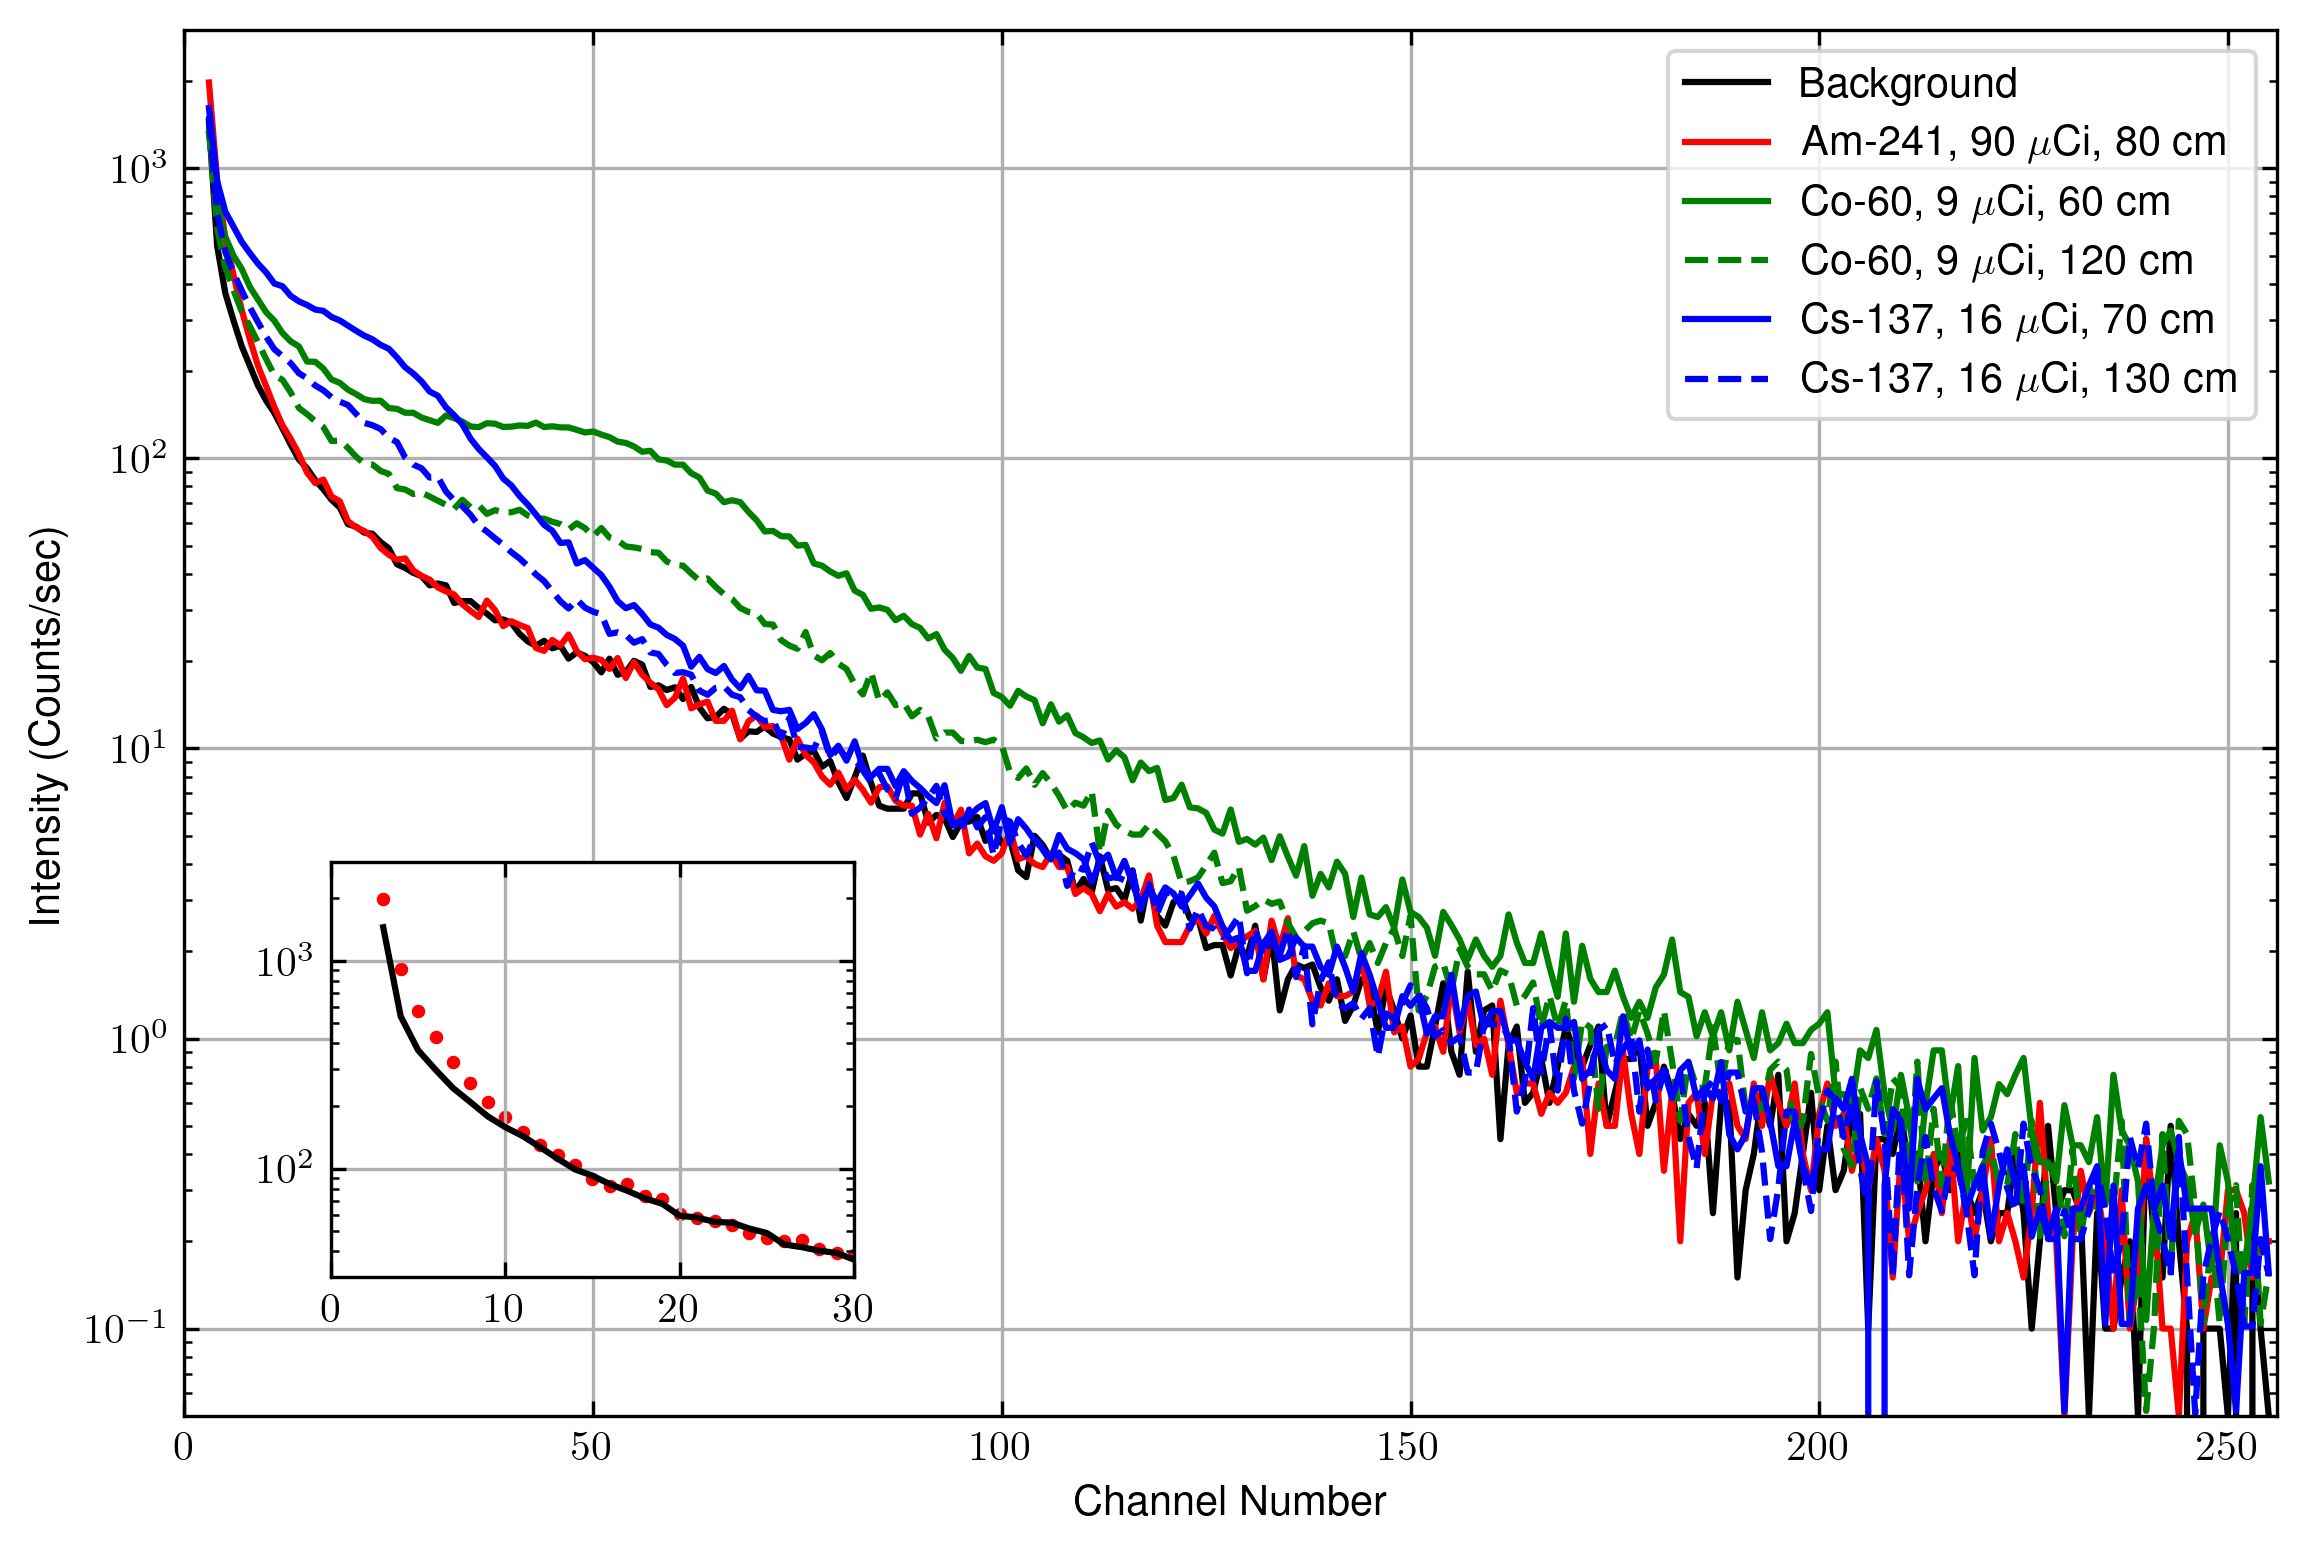

In [4]:
# # PN1 data

# ni = 3
# Specs1 = pd.DataFrame( {
#     "bkg" : read_mca(pn1files[0])[ni:], 
#     "am_80" : read_mca(pn1files[1])[ni:],
#     "am_180" : read_mca(pn1files[2])[ni:],
#     "am_280" : read_mca(pn1files[3])[ni:],
#     "am_460" : read_mca(pn1files[4])[ni:],
#     "cs_70" : read_mca(pn1files[5])[ni:],
#     "cs_130" : read_mca(pn1files[6])[ni:],
#     "cs_300" : read_mca(pn1files[7])[ni:],
#     "cs_390" : read_mca(pn1files[8])[ni:],
#     "co_60" :  read_mca(pn1files[9])[ni:],
#     "co_120" : read_mca(pn1files[10])[ni:],
#     "co_310" :  read_mca(pn1files[11])[ni:],
#     "co_470" :  read_mca(pn1files[12])[ni:],
#     "co_cs_136" : read_mca(pn1files[13])[ni:],
#     "am_co_287" : read_mca(pn1files[14])[ni:],
#     "co_cs_361" : read_mca(pn1files[15])[ni:],
#     "am_cs_163" : read_mca(pn1files[16])[ni:],
#     "am_co_cs_309" : read_mca(pn1files[17])[ni:],
#     "am_210_co_153" : read_mca(pn1files[18])[ni:],
#     "co_285_cs_367" : read_mca(pn1files[19])[ni:],
#     "am_85_cs_173" : read_mca(pn1files[20])[ni:],
#     "co_223_cs_316" : read_mca(pn1files[21])[ni:]     
# })

# for kk in Specs1.keys():
#     Specs1[kk] = Specs1[kk]/float(HeaderInfo[kk]["LIVE_TIME"])

# # PN2 data
# Specs2 = pd.DataFrame( {
#     "bkg" : read_mca(pn2files[0])[ni:], 
#     "am_80" : read_mca(pn2files[1])[ni:],
#     "cs_70" : read_mca(pn2files[5])[ni:],
#     "cs_130" : read_mca(pn2files[6])[ni:],
#     "co_120" : read_mca(pn2files[10])[ni:],
#     "co_60" :  read_mca(pn2files[9])[ni:],
#     "co_cs_136" : read_mca(pn2files[13])[ni:],
#     "am_co_287" : read_mca(pn2files[14])[ni:],
#     "co_cs_361" : read_mca(pn2files[15])[ni:],
#     "am_cs_163" : read_mca(pn2files[16])[ni:],
#     "am_co_cs_309" : read_mca(pn2files[17])[ni:],
#     "am_210_co_153" : read_mca(pn2files[18])[ni:],
#     "co_285_cs_367" : read_mca(pn2files[19])[ni:],
#     "am_85_cs_173" : read_mca(pn2files[20])[ni:],
#     "co_223_cs_316" : read_mca(pn2files[21])[ni:]
        
# })


# for kk in Specs2.keys():
#     Specs2[kk] = Specs2[kk]/float(HeaderInfo[kk]["LIVE_TIME"])
ni=3    
plt.figure(figsize=(9, 6), dpi=300)
channel = np.arange(ni,len(Specs1["bkg"])+ni)
plt.plot(channel, Specs1["bkg"], color="black", label = "Background")
plt.plot(channel, Specs1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")

plt.legend()
plt.grid()
plt.yscale("log", base=10)
plt.ylim(0.05, 3e3)
plt.xlim(0, 256)
plt.xlabel("Channel Number")
plt.ylabel("Intensity (Counts/sec)")

ax = plt.gca()
x1, x2, y1, y2 = 0, 30, 3e1, 3.0e3  # subregion of the original image
axins = ax.inset_axes(
    [0.07, 0.1, 0.25, 0.3],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
axins.plot(channel, Specs1["bkg"], color="black", label = "Background")
axins.scatter(channel, Specs1["am_80"], color = "red", s=5, label = "Am-241, 90 $\\mu$Ci, 80 cm")
# axins.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
# axins.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
# axins.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
# axins.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)
# plt.title("Fig 1")



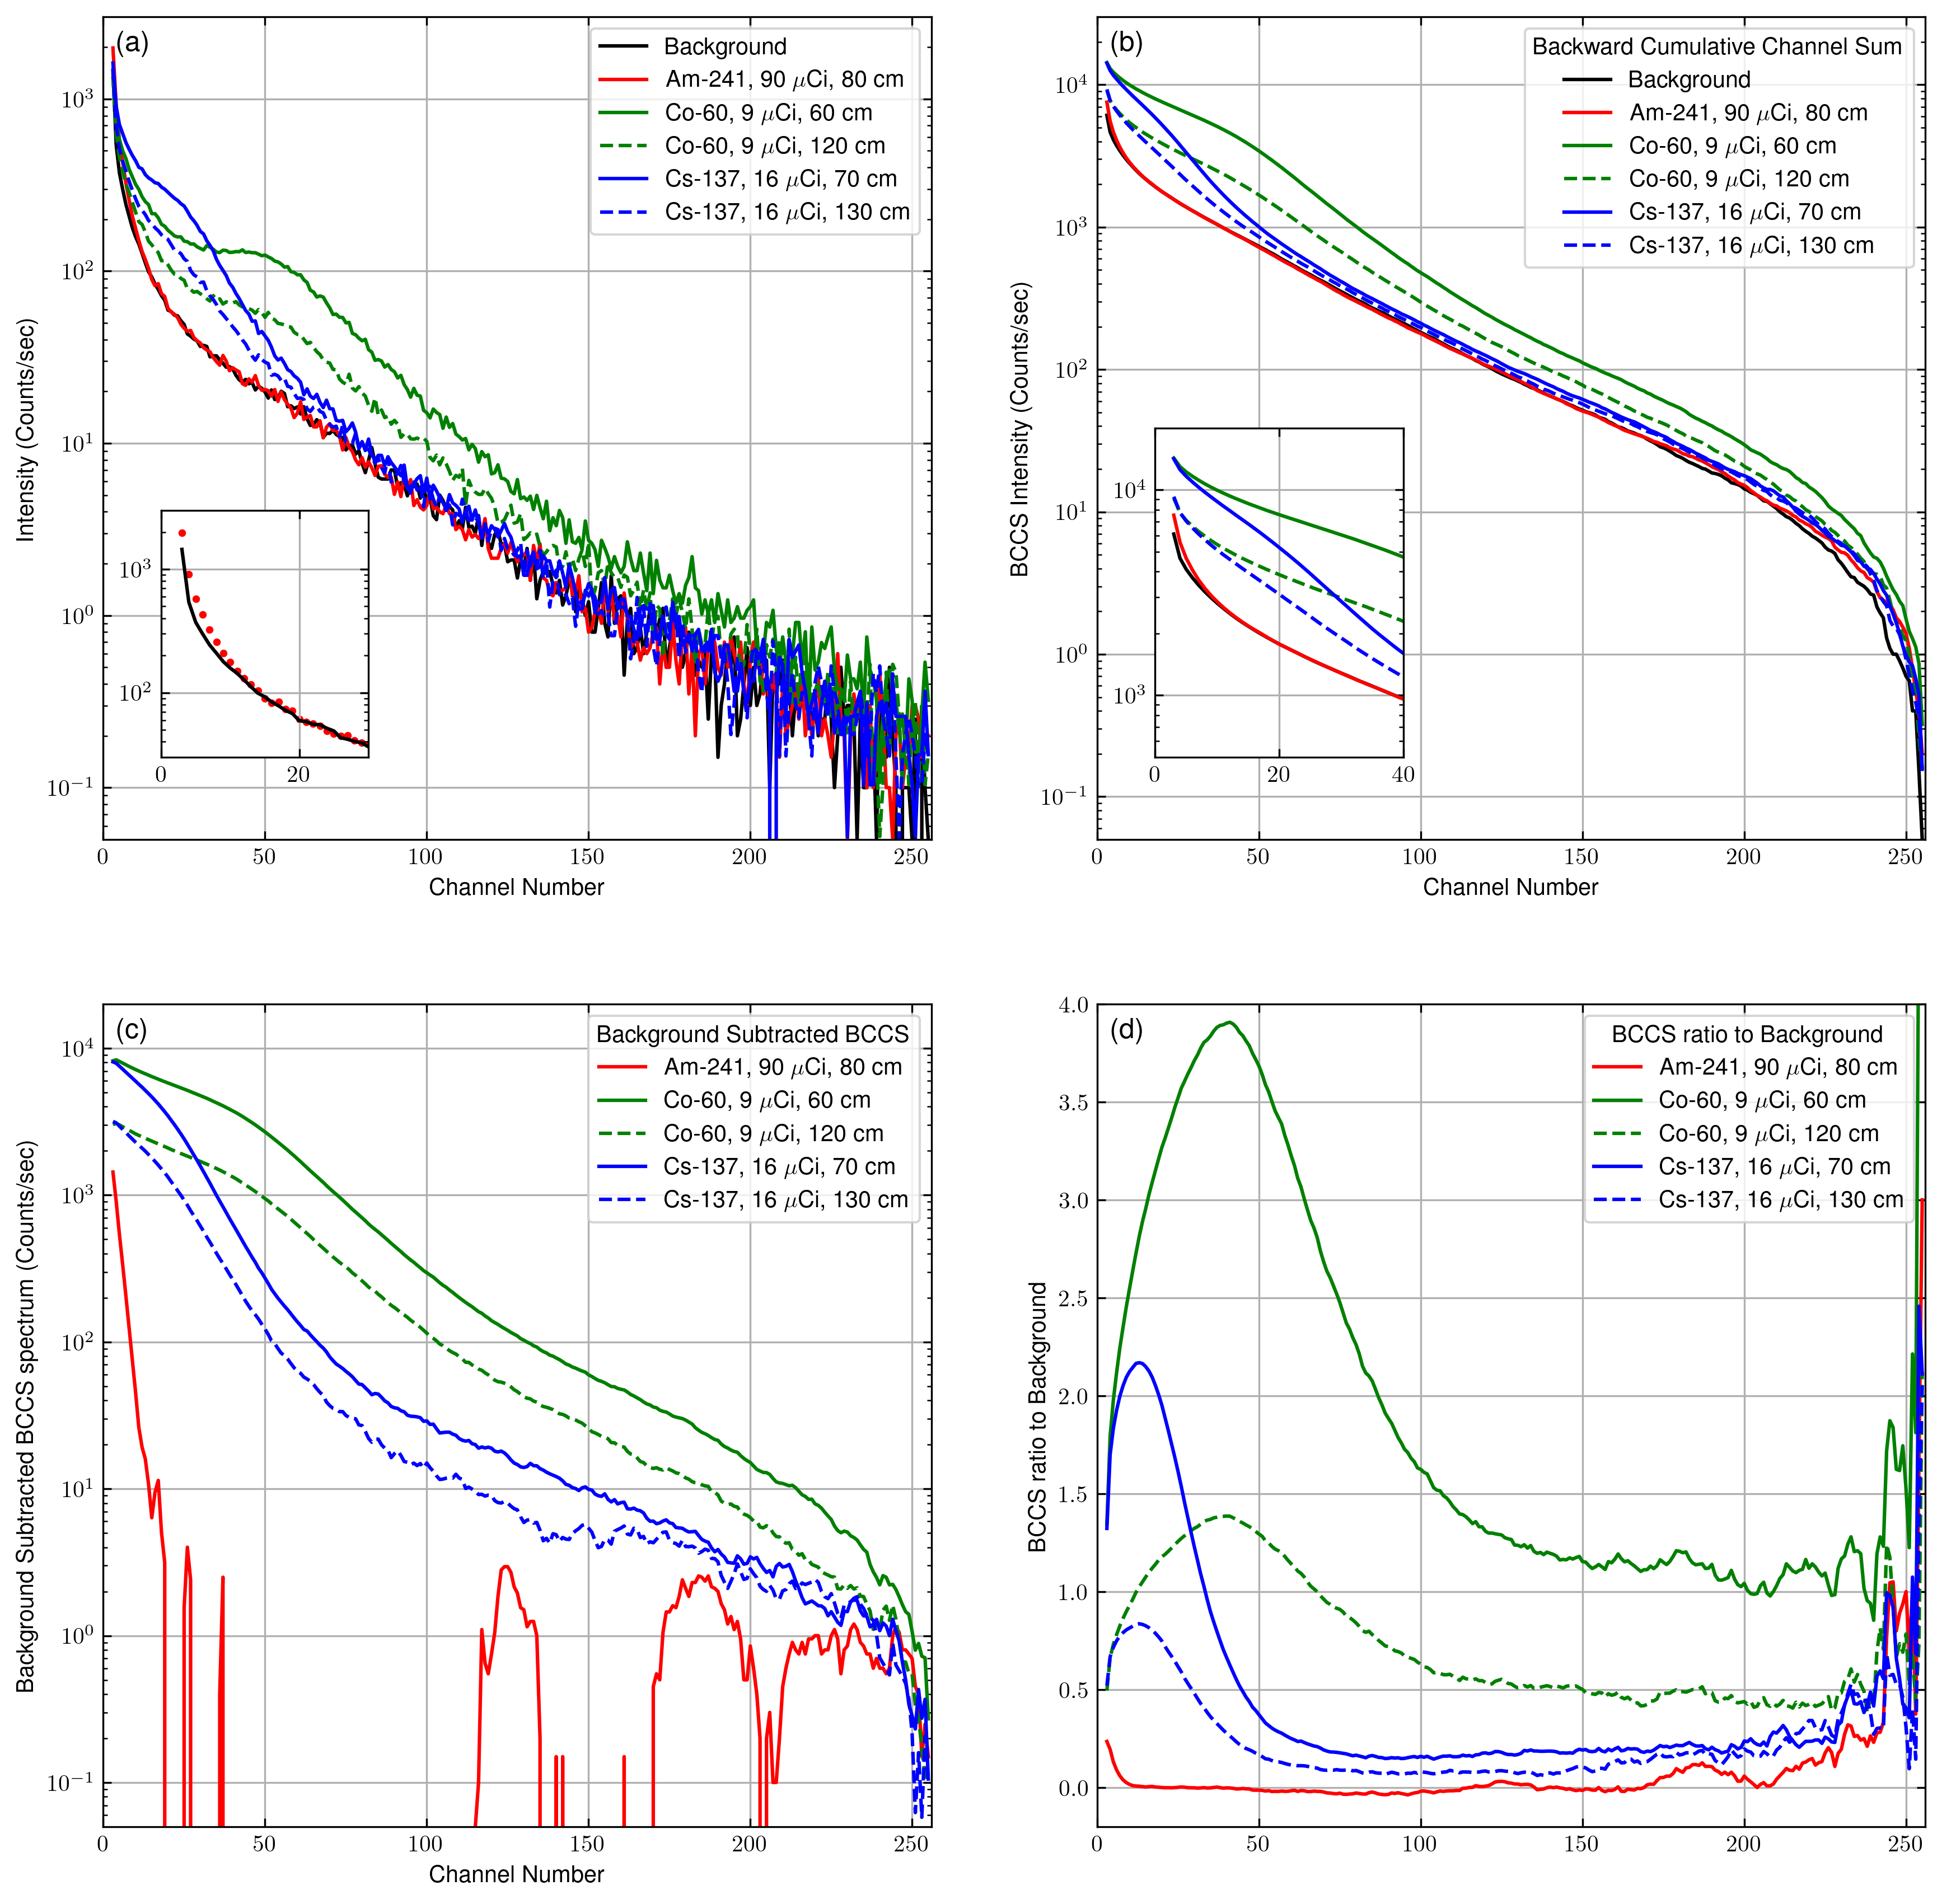

In [5]:
_bccs1, _bccs2, _bccsbkg1, _bccsbkg2, _bccsrto1, _bccsrto2 = {}, {}, {}, {}, {}, {}
for kk in Specs1.keys():
    _bccs1[kk] = bccs(Specs1[kk])
    if kk == "bkg":
        _bkg1 = bccs(Specs1[kk])
    else :
        _bccsbkg1[kk] = _bccs1[kk] - _bkg1
        _bccsrto1[kk] =  _bccs1[kk] / _bkg1 - 1.0

for kk in Specs2.keys():
    _bccs2[kk] = bccs(Specs2[kk])
    if kk == "bkg":
        _bkg2 = bccs(Specs2[kk])
    else :
        _bccsbkg2[kk] = _bccs1[kk] - _bkg2
        _bccsrto2[kk] = _bccs1[kk] / _bkg2 - 1.0


BCCS1 = pd.DataFrame(_bccs1)
BCCS2 = pd.DataFrame(_bccs2)
BCCSSub1 = pd.DataFrame(_bccsbkg1)
BCCSSub2 = pd.DataFrame(_bccsbkg2)
BCCSRto1 = pd.DataFrame(_bccsrto1)
BCCSRto2 = pd.DataFrame(_bccsrto2)

plt.figure(figsize=(14, 14), dpi=300)
plt.subplot(221)
channel = np.arange(ni,len(Specs1["bkg"])+ni)
plt.plot(channel, Specs1["bkg"], color="black", label = "Background")
plt.plot(channel, Specs1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")

plt.legend()
plt.grid()
plt.yscale("log", base=10)
plt.ylim(0.05, 3e3)
plt.xlim(0, 256)
plt.xlabel("Channel Number")
plt.ylabel("Intensity (Counts/sec)")

ax = plt.gca()
x1, x2, y1, y2 = 0, 30, 3e1, 3.0e3  # subregion of the original image
axins = ax.inset_axes(
    [0.07, 0.1, 0.25, 0.3],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
axins.plot(channel, Specs1["bkg"], color="black", label = "Background")
axins.scatter(channel, Specs1["am_80"], color = "red", s=5, label = "Am-241, 90 $\\mu$Ci, 80 cm")
# axins.plot(channel, Specs1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
# axins.plot(channel, Specs1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
# axins.plot(channel, Specs1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
# axins.plot(channel, Specs1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)
ax.annotate(
        "(a)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')#, fontfamily='serif'
        # bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
# plt.title("Fig 1")



# plt.figure(figsize=(14, 6), dpi=300)
plt.subplot(222)
plt.plot(channel, BCCS1["bkg"], color="black", label = "Background")
plt.plot(channel, BCCS1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, BCCS1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, BCCS1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, BCCS1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, BCCS1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")


plt.legend(title = "Backward Cumulative Channel Sum")
plt.grid()
plt.yscale("log", base=10)
plt.ylim(0.05, 3e4)
plt.xlim(0, 256)

plt.xlabel("Channel Number")
plt.ylabel("BCCS Intensity (Counts/sec)")

ax = plt.gca()
ff = plt.gcf()
ax.annotate(
        "(b)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')#, fontfamily='serif'
        # bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0))
x1, x2, y1, y2 = 0, 40, 5e2, 2.0e4  
axins = ax.inset_axes(
    [0.07, 0.1, 0.3, 0.4],
    xlim=(x1, x2), ylim=(y1, y2))#, xticklabels=[0, 20, 40], yticklabels=[1.0e3, 1.0e4])
axins.plot(channel, BCCS1["bkg"], color="black", label = "Background")
axins.plot(channel, BCCS1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
axins.plot(channel, BCCS1["co_60"], color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
axins.plot(channel, BCCS1["co_120"], "--", color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
axins.plot(channel, BCCS1["cs_70"],  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
axins.plot(channel, BCCS1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
axins.set_yscale("log", base=10)
axins.grid(True)
# plt.title("Fig 2.-PN1")

# plt.subplot(122)
# plt.plot(channel, BCCS2["bkg"], color="black", label = "Background")
# plt.plot(channel, BCCS2["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
# plt.plot(channel, BCCS2["co_120"], color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
# plt.plot(channel, BCCS2["co_60"], "--", color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
# plt.plot(channel, BCCS2["cs_130"], color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
# plt.plot(channel, BCCS2["cs_70"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")

# plt.legend(title = "Channel sum")
# plt.grid()
# plt.yscale("log", base=10)
# plt.ylim(1, 5e5)
# plt.xlim(0, 256)
# plt.title("Fig 2.-PN2")

plt.subplot(223)
plt.plot(channel, BCCSSub1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, BCCSSub1["co_60"] ,  color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, BCCSSub1["co_120"], "--",color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, BCCSSub1["cs_70"] ,  color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, BCCSSub1["cs_130"], "--",color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")


plt.legend(title="Background Subtracted BCCS")
plt.grid()
plt.yscale("log", base=10)
plt.ylim(0.05, 2e4)
plt.xlim(0, 256)
plt.xlabel("Channel Number")
plt.ylabel("Background Subtracted BCCS spectrum (Counts/sec)")
ax = plt.gca()
ax.annotate(
        "(c)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')
# plt.savefig("../../src/newfigures/figure2.pdf")

plt.subplot(224)
plt.plot(channel, BCCSRto1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, BCCSRto1["co_60"] ,  color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, BCCSRto1["co_120"], "--",color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, BCCSRto1["cs_70"] , color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.plot(channel, BCCSRto1["cs_130"], "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
plt.ylabel("BCCS ratio to Background")
plt.legend(title="BCCS ratio to Background")
plt.grid()
#plt.yscale("log", base=10)
plt.ylim(-0.2, 4)
plt.xlim(0, 256)
ax = plt.gca()
ff = plt.gcf()
ax.annotate(
        "(d)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')

if FLAG_savefig:
    plt.savefig(os.path.join(current_paper_directory, "figure1.pdf"))

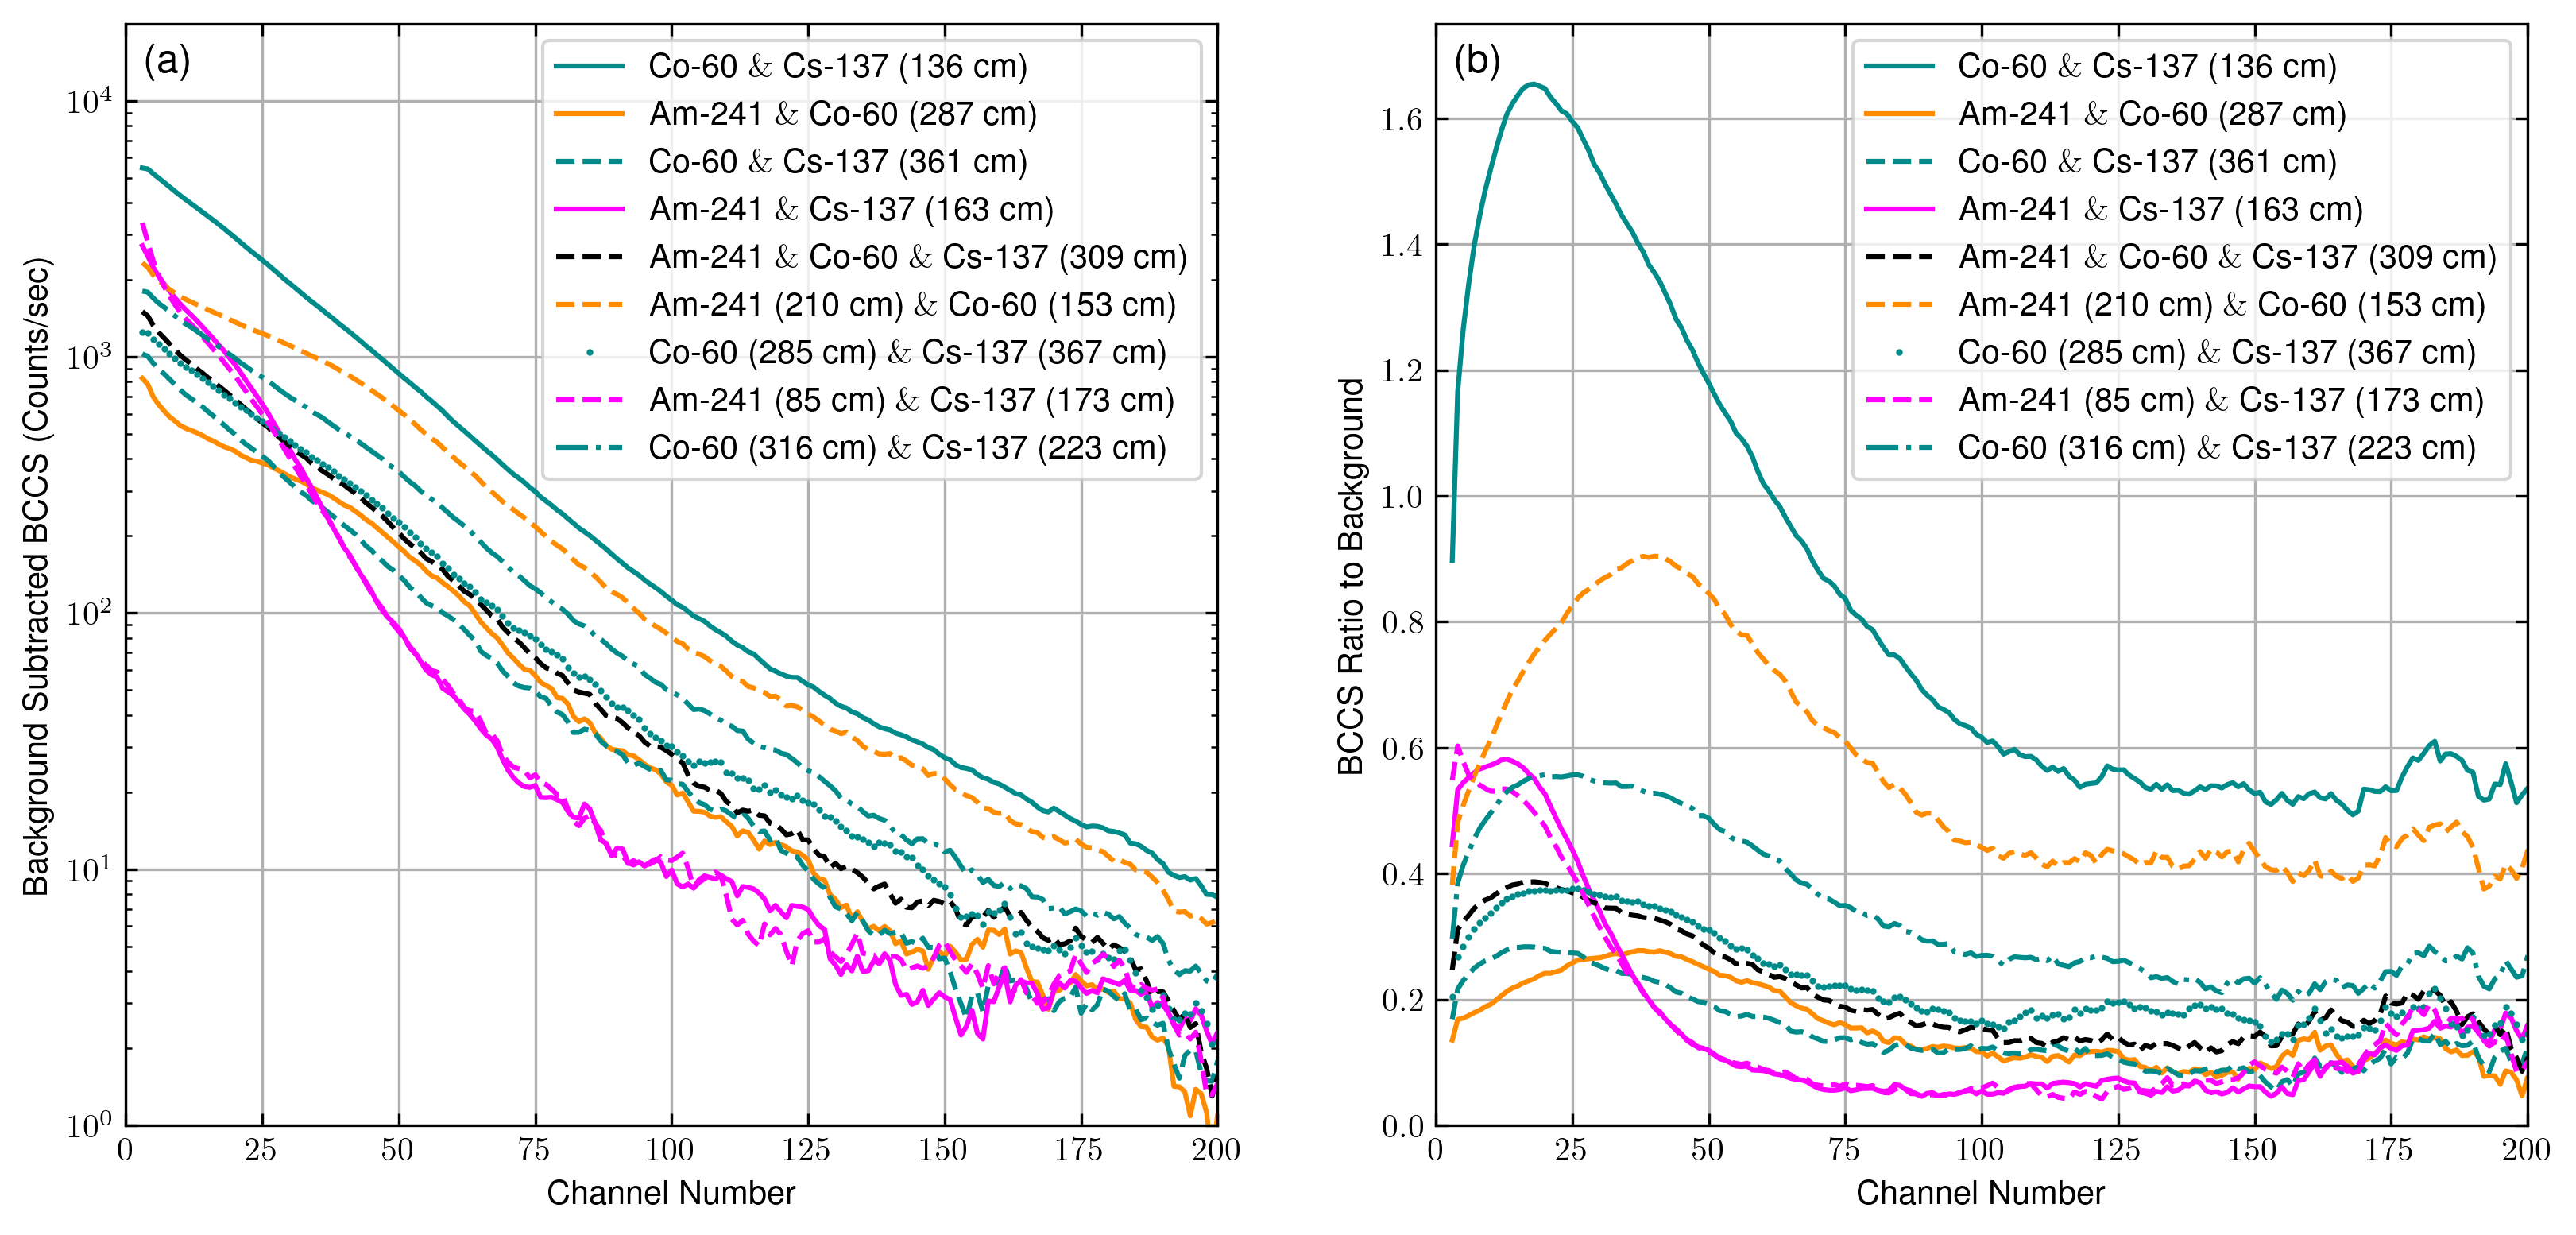

In [6]:
plt.figure(figsize=(13, 6), dpi = 300)
plt.subplot(121)
plt.plot(channel, BCCSSub1["co_cs_136"], color = "darkcyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
plt.plot(channel, BCCSSub1["am_co_287"], color = "darkorange", label = "Am-241 $\\&$ Co-60 (287 cm)")
plt.plot(channel, BCCSSub1["co_cs_361"] , "--", color = "darkcyan", label = "Co-60 $\\&$  Cs-137 (361 cm)")
plt.plot(channel, BCCSSub1["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (163 cm)")
plt.plot(channel, BCCSSub1["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
plt.plot(channel, BCCSSub1["am_210_co_153"] , "--", color="darkorange", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.plot(channel, BCCSSub1["co_285_cs_367"] , ".", ms=2, color="darkcyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.plot(channel, BCCSSub1["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.plot(channel, BCCSSub1["co_316_cs_223"] , "-.", color="darkcyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")

plt.grid()
plt.yscale("log", base=10)
plt.ylim(1, 2e4)
plt.xlim(0, 200)
plt.xlabel("Channel Number")
plt.ylabel("Background Subtracted BCCS (Counts/sec)")
plt.legend()
ax = plt.gca()
ax.annotate(
    "(a)",
    xy=(0, 1), xycoords='axes fraction',
    xytext=(+0.5, -0.5), textcoords='offset fontsize',
    fontsize='large', verticalalignment='top')

# plt.subplot(122)
# plt.plot(channel, BCCSSub2["co_cs_136"], color = "cyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
# plt.plot(channel, BCCSSub2["am_co_287"], color = "olive", label = "Am-241 $\\&$ Co-60 (287 cm)")
# plt.plot(channel, BCCSSub2["co_cs_361"] , "--", color = "cyan", label = "Co-60 $\\&$ Cs-137 (361 cm)")
# plt.plot(channel, BCCSSub2["am_cs_63"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (63 cm)")
# plt.plot(channel, BCCSSub2["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
# plt.plot(channel, BCCSSub2["am_210_co_153"] , "--", color="olive", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
# plt.plot(channel, BCCSSub2["co_285_cs_367"] , ".", color="cyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
# plt.plot(channel, BCCSSub2["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
# plt.plot(channel, BCCSSub2["co_316_cs_223"] , "-.", color="cyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")
# plt.legend(title="Background Subtracted Channel Sum")
# plt.grid()
# plt.yscale("log", base=10)
# plt.ylim(1, 1.2e5)
# plt.xlim(0, 256)
# ax = plt.gca()
# ax.annotate(
#         "(b)",
#         xy=(0, 1), xycoords='axes fraction',
#         xytext=(+0.5, -0.5), textcoords='offset fontsize',
#         fontsize='large', verticalalignment='top')
plt.subplot(122)
plt.plot(channel, BCCSRto1["co_cs_136"], color = "darkcyan", label = "Co-60 $\\&$ Cs-137 (136 cm)")
plt.plot(channel, BCCSRto1["am_co_287"], color = "darkorange", label = "Am-241 $\\&$ Co-60 (287 cm)")
plt.plot(channel, BCCSRto1["co_cs_361"] , "--", color = "darkcyan", label = "Co-60 $\\&$  Cs-137 (361 cm)")
plt.plot(channel, BCCSRto1["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137 (163 cm)")
plt.plot(channel, BCCSRto1["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137 (309 cm)")
plt.plot(channel, BCCSRto1["am_210_co_153"] , "--", color="darkorange", label = "Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.plot(channel, BCCSRto1["co_285_cs_367"] , ".", ms=2, color="darkcyan", label = "Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.plot(channel, BCCSRto1["am_85_cs_173"] , "--", color="magenta", label = "Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.plot(channel, BCCSRto1["co_316_cs_223"] , "-.", color="darkcyan", label = "Co-60 (316 cm) $\\&$ Cs-137 (223 cm)")

plt.grid()
# plt.yscale("log", base=10)
plt.ylim(0, 1.75)
plt.xlim(0, 200)
plt.xlabel("Channel Number")
plt.ylabel("BCCS Ratio to Background")
plt.legend()
ax = plt.gca()
ax.annotate(
        "(b)",
        xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='top')

if FLAG_savefig:
    plt.savefig(os.path.join(current_paper_directory, "figure2.pdf"))
    print("Saved")

Text(0.5, 1.0, 'Fig 3')

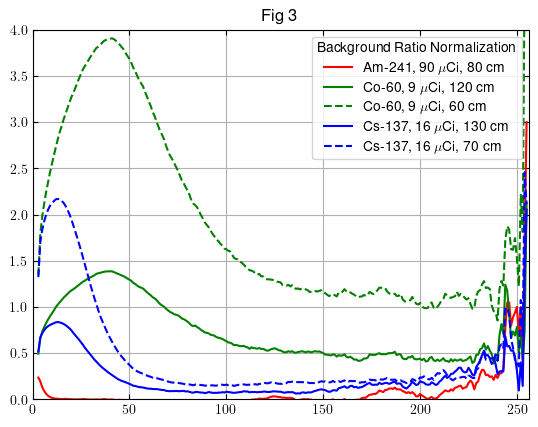

In [7]:
plt.plot(channel, BCCSRto1["am_80"], color = "red", label = "Am-241, 90 $\\mu$Ci, 80 cm")
plt.plot(channel, BCCSRto1["co_120"], color = "green", label = "Co-60, 9 $\\mu$Ci, 120 cm")
plt.plot(channel, BCCSRto1["co_60"] , "--", color="green", label = "Co-60, 9 $\\mu$Ci, 60 cm")
plt.plot(channel, BCCSRto1["cs_130"], color = "blue", label = "Cs-137, 16 $\\mu$Ci, 130 cm")
plt.plot(channel, BCCSRto1["cs_70"] , "--", color = "blue", label = "Cs-137, 16 $\\mu$Ci, 70 cm")
plt.legend(title="Background Ratio Normalization")
plt.grid()
#plt.yscale("log", base=10)
plt.ylim(0, 4)
plt.xlim(0, 256)
plt.title("Fig 3")

Text(0.5, 1.0, 'Fig 4-PN2')

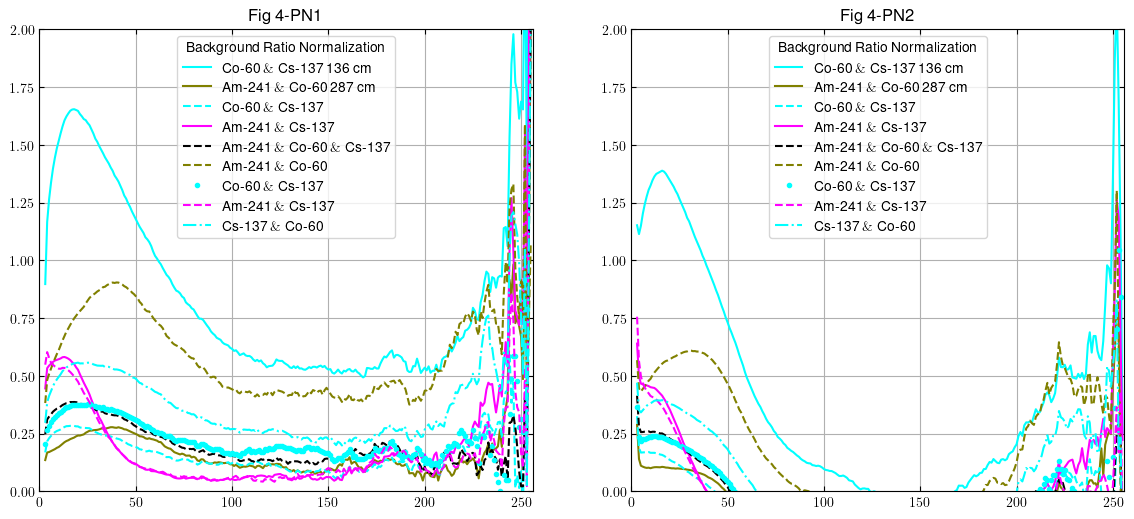

In [8]:
plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.plot(channel, BCCSRto1["co_cs_136"], color = "cyan", label = "Co-60 $\\&$ Cs-137 136 cm")
plt.plot(channel, BCCSRto1["am_co_287"], color = "olive", label = "Am-241 $\\&$ Co-60 287 cm")
plt.plot(channel, BCCSRto1["co_cs_361"] , "--", color = "cyan", label = "Co-60 $\\&$  Cs-137 ")
plt.plot(channel, BCCSRto1["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137")
plt.plot(channel, BCCSRto1["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137")
plt.plot(channel, BCCSRto1["am_210_co_153"] , "--", color="olive", label = "Am-241 $\\&$ Co-60")
plt.plot(channel, BCCSRto1["co_285_cs_367"] , ".", color="cyan", label = "Co-60 $\\&$ Cs-137")
plt.plot(channel, BCCSRto1["am_85_cs_173"] , "--", color="magenta", label = "Am-241 $\\&$ Cs-137")
plt.plot(channel, BCCSRto1["co_316_cs_223"] , "-.", color="cyan", label = "Cs-137 $\\&$ Co-60")
plt.legend(title="Background Ratio Normalization")
plt.grid()
# plt.yscale("log", base=10)
plt.ylim(0, 2)
plt.xlim(0, 256)
plt.title("Fig 4-PN1")

plt.subplot(122)
plt.plot(channel, BCCSRto2["co_cs_136"], color = "cyan", label = "Co-60 $\\&$ Cs-137 136 cm")
plt.plot(channel, BCCSRto2["am_co_287"], color = "olive", label = "Am-241 $\\&$ Co-60 287 cm")
plt.plot(channel, BCCSRto2["co_cs_361"] , "--", color = "cyan", label = "Co-60 $\\&$  Cs-137 ")
plt.plot(channel, BCCSRto2["am_cs_163"], color = "magenta", label = "Am-241 $\\&$ Cs-137")
plt.plot(channel, BCCSRto2["am_co_cs_309"] , "--", color="black", label = "Am-241 $\\&$ Co-60 $\\&$ Cs-137")
plt.plot(channel, BCCSRto2["am_210_co_153"] , "--", color="olive", label = "Am-241 $\\&$ Co-60")
plt.plot(channel, BCCSRto2["co_285_cs_367"] , ".", color="cyan", label = "Co-60 $\\&$ Cs-137")
plt.plot(channel, BCCSRto2["am_85_cs_173"] , "--", color="magenta", label = "Am-241 $\\&$ Cs-137")
plt.plot(channel, BCCSRto2["co_316_cs_223"] , "-.", color="cyan", label = "Cs-137 $\\&$ Co-60")
plt.legend(title="Background Ratio Normalization")
plt.grid()
# plt.yscale("log", base=10)
plt.ylim(0, 2)
plt.xlim(0, 256)
plt.title("Fig 4-PN2")

In [9]:
BCCSSub1

,am_80,cs_70,cs_130,co_120,co_60,co_cs_136,am_co_287,co_cs_361,am_cs_163,am_co_cs_309,am_210_co_153,co_285_cs_367,am_85_cs_173,co_316_cs_223
0,1434.80,8066.759116,3170.934683,3018.401353,8206.809254,5471.627877,825.312523,1027.841205,2717.218647,1505.000296,2331.373744,1247.366394,3343.297627,1807.914689
1,906.70,7901.345323,3104.735884,3084.607492,8339.945673,5422.288763,781.849197,1006.271901,2479.206970,1446.867539,2238.406939,1243.708422,2802.597382,1790.477966
2,539.10,7538.240915,2943.319937,3003.457284,8127.489417,5194.620586,698.896839,945.329286,2237.250489,1328.684393,2088.326748,1169.476983,2374.647607,1698.205521
3,336.05,7200.144524,2799.812284,2918.357700,7917.544773,4995.208765,651.310886,896.057162,2064.837426,1246.525723,1987.695106,1118.914759,2082.093664,1621.688367
4,205.65,6869.555227,2663.131437,2837.284860,7716.437661,4802.466317,615.334265,859.035656,1926.401111,1184.945361,1905.856163,1073.117130,1884.571213,1563.728942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,0.45,0.231560,0.062396,0.338554,0.796015,1.074679,0.315643,-0.041357,0.470848,0.014146,0.489306,0.167661,0.065966,0.325860
249,0.40,0.429703,0.159739,0.276379,0.885347,1.011101,0.413173,0.157922,0.618953,0.161970,0.635733,0.366558,0.213685,0.421777
250,0.15,0.274134,0.057969,0.172320,0.724679,0.540734,0.209880,0.056482,0.364214,0.059794,0.169653,0.315454,0.009123,0.010889
251,0.25,0.368565,0.206198,0.110146,0.706898,0.372630,0.154940,0.103601,0.257581,0.156529,0.108933,0.309935,0.207983,0.158166


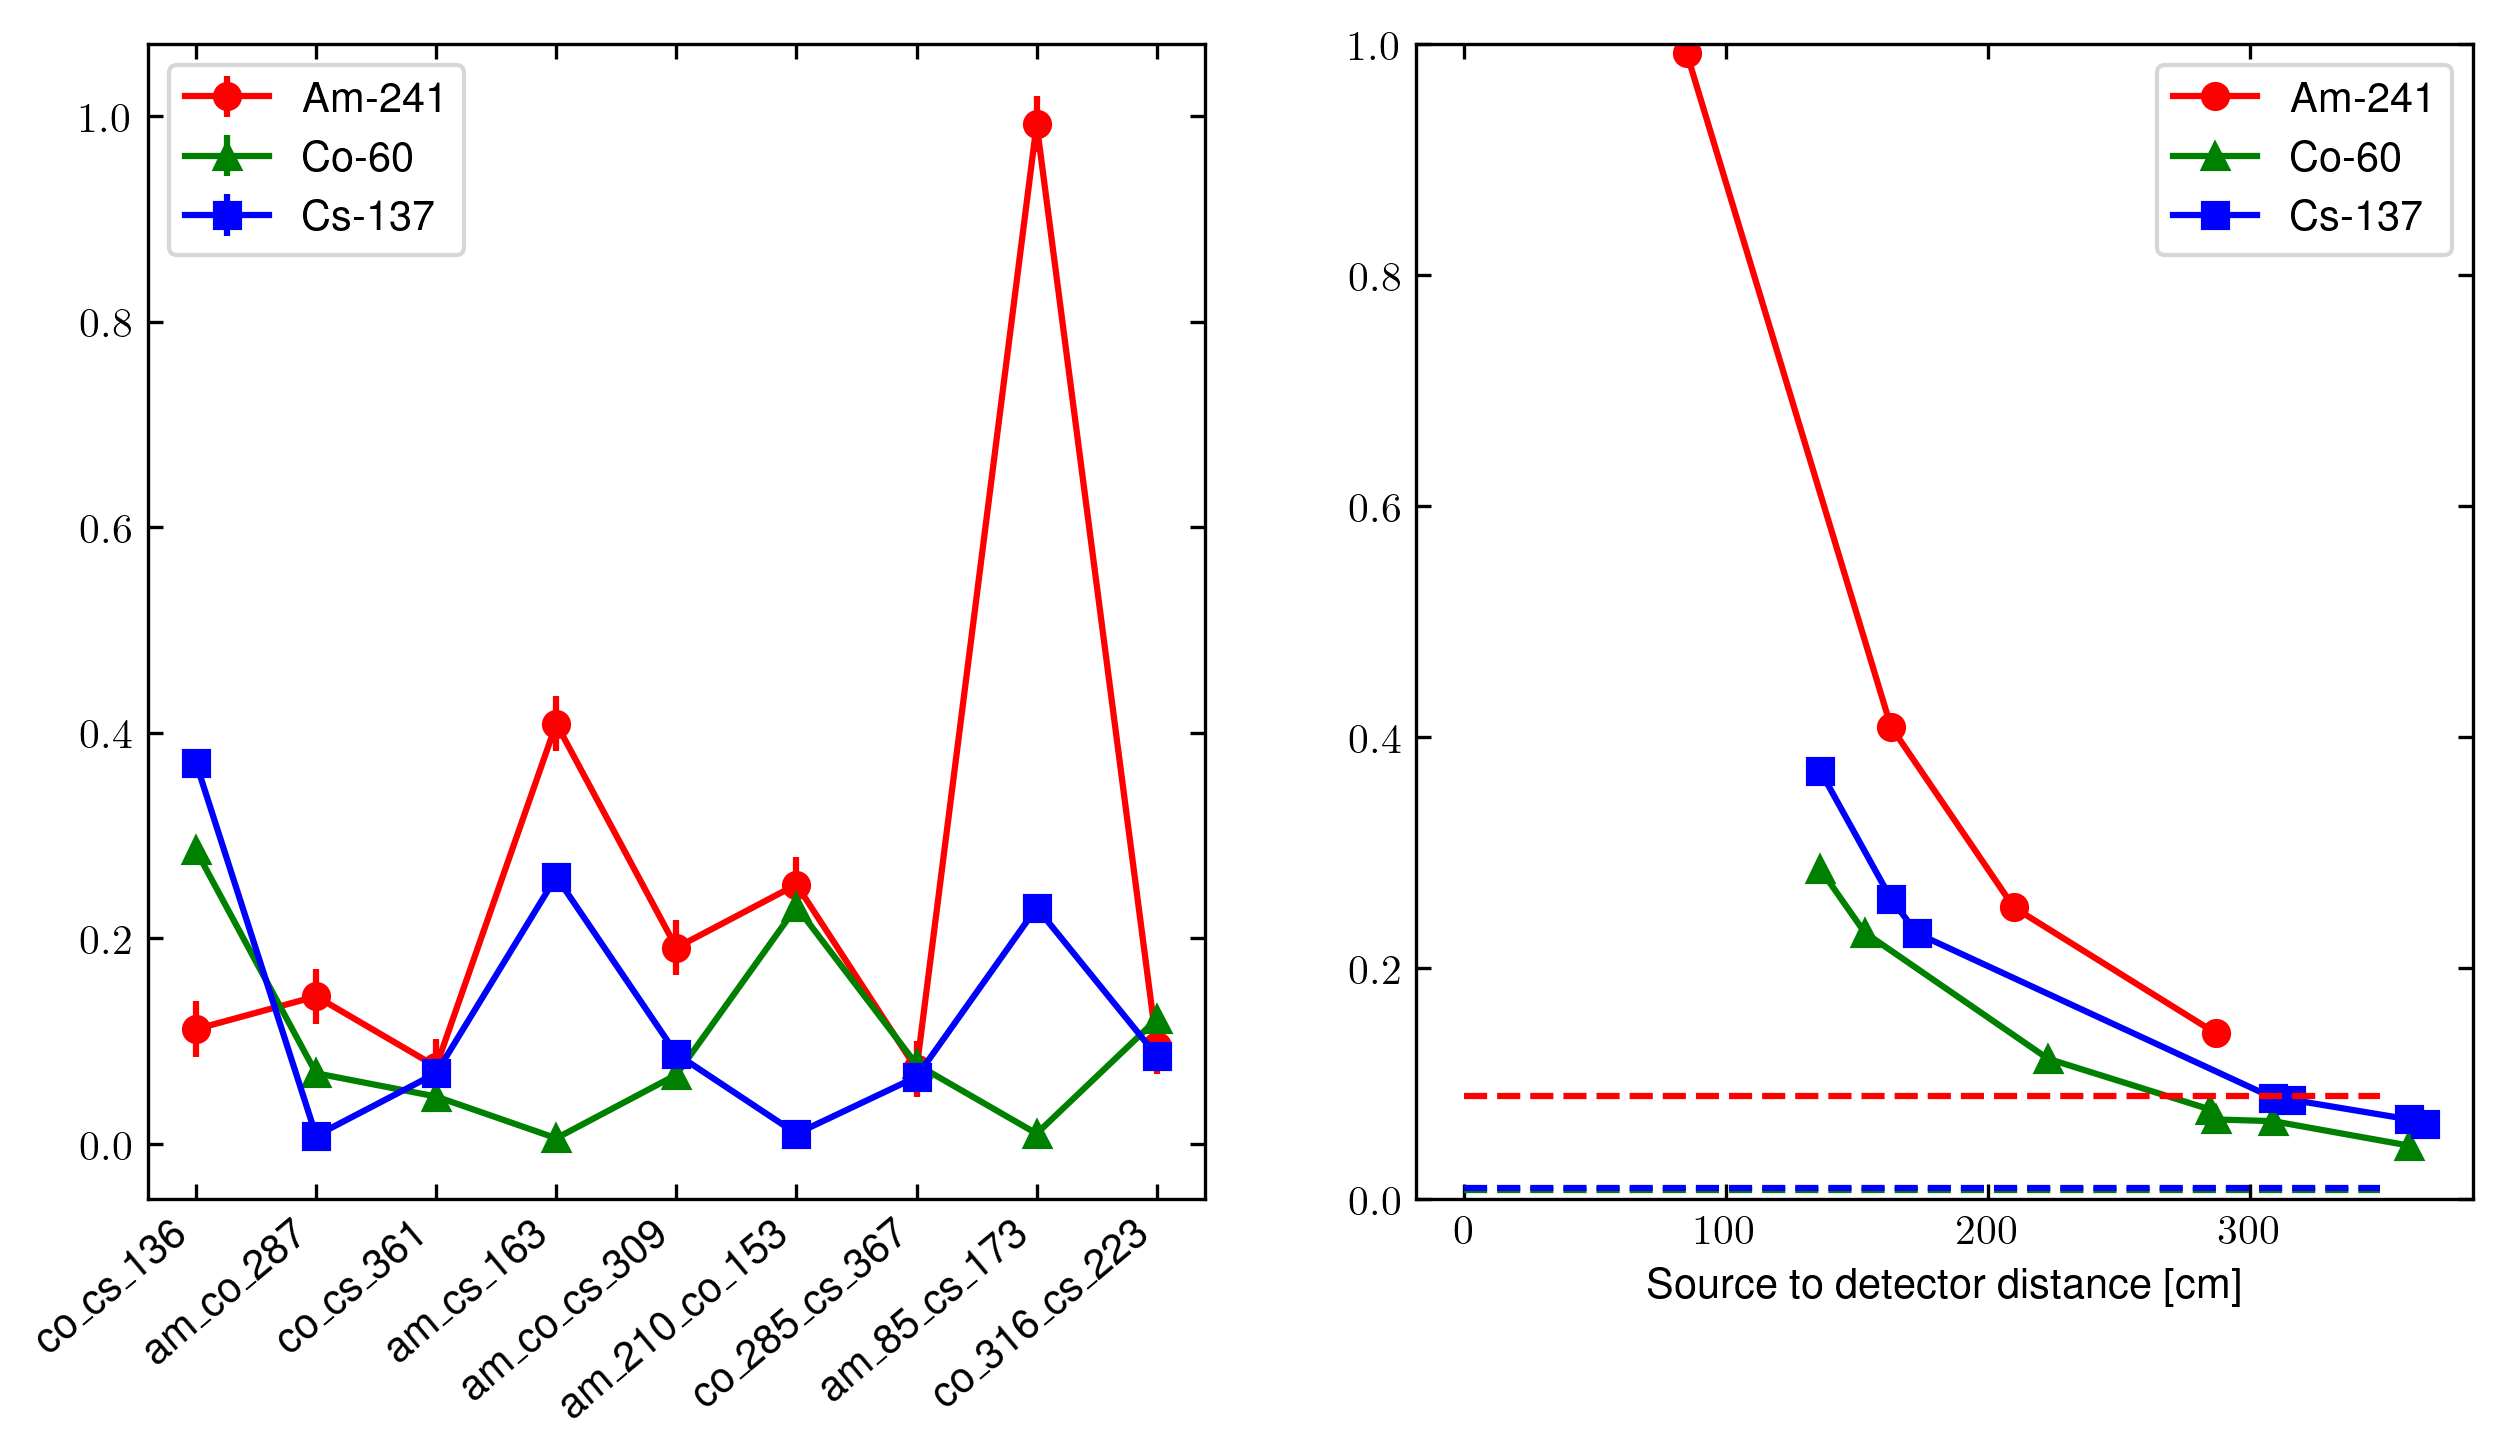

In [10]:
_refspecSub= {"Am" : BCCSSub1["am_80"], "Co" :BCCSSub1["co_60"], "Cs":BCCSSub1["cs_70"]}
mixed = ("co_cs_136", "am_co_287", "co_cs_361", "am_cs_163", "am_co_cs_309", "am_210_co_153",
         "co_285_cs_367", "am_85_cs_173", "co_316_cs_223")

BCCSFitSubResult0, BCCSFitSubResult = {}, {}
for kk in mixed :
     popt, se, pconv = BCCSfit((0.5, 0.5, 0.5), BCCSSub1[kk], _refspecSub, 252, False)
     BCCSFitSubResult0[kk] = (popt, se, pconv)
     BCCSFitSubResult[kk] = {}
     BCCSFitSubResult[kk]["am"] = [float(c) for c in (float(popt[0]), float(np.sqrt(se[0])))]
     BCCSFitSubResult[kk]["co"] = [float(c) for c in (float(popt[1]), float(np.sqrt(se[1])))]
     BCCSFitSubResult[kk]["cs"] = [float(c) for c in (float(popt[2]), float(np.sqrt(se[1])))]

v_am, v_co, v_cs, e_am, e_co, e_cs = [], [], [], [], [], []
for kk in mixed :
     v_am.append(BCCSFitSubResult[kk]["am"][0])
     e_am.append(BCCSFitSubResult[kk]["am"][1])
     v_co.append(BCCSFitSubResult[kk]["co"][0])
     e_co.append(BCCSFitSubResult[kk]["co"][1])
     v_cs.append(BCCSFitSubResult[kk]["cs"][0])
     e_cs.append(BCCSFitSubResult[kk]["cs"][1])

plt.figure(figsize=(10, 5), dpi = 300)
plt.subplot(121)
plt.errorbar(mixed, v_am, e_am, color="red", marker="o", label = "Am-241")
plt.errorbar(mixed, v_co, e_co, color="green", marker="^", label = "Co-60")
plt.errorbar(mixed, v_cs, e_cs, color="blue", marker="s", label = "Cs-137")
ax=plt.gca()
ax.set_xticks(np.arange(0, len(mixed)))
ax.set_xticklabels(mixed, rotation=40, ha='right')
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitSubResult["am_co_287"]["am"][0], BCCSFitSubResult["am_cs_163"]["am"][0], BCCSFitSubResult["am_210_co_153"]["am"][0], BCCSFitSubResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitSubResult["co_cs_136"]["co"][0], BCCSFitSubResult["am_co_287"]["co"][0], BCCSFitSubResult["co_cs_361"]["co"][0], BCCSFitSubResult["am_co_cs_309"]["co"][0], BCCSFitSubResult["am_210_co_153"]["co"][0], BCCSFitSubResult["co_285_cs_367"]["co"][0], BCCSFitSubResult["co_316_cs_223"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitSubResult["co_cs_136"]["cs"][0], BCCSFitSubResult["co_cs_361"]["cs"][0], BCCSFitSubResult["am_cs_163"]["cs"][0], BCCSFitSubResult["am_co_cs_309"]["cs"][0], BCCSFitSubResult["co_285_cs_367"]["cs"][0], BCCSFitSubResult["am_85_cs_173"]["cs"][0], BCCSFitSubResult["co_316_cs_223"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(0, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(BCCSFitSubResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(BCCSFitSubResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(BCCSFitSubResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.legend()


In [11]:
BCCSFitSubResult


{'co_cs_136': {'am': [0.11170682680351784, 0.02698066180799086],
  'co': [0.28557897836037993, 0.007938671563289704],
  'cs': [0.37065683091629176, 0.007938671563289704]},
 'am_co_287': {'am': [0.14360276991889978, 0.026980662090295274],
  'co': [0.06880926196310086, 0.00793867168018822],
  'cs': [0.00800732472995806, 0.00793867168018822]},
 'co_cs_361': {'am': [0.07529545023609199, 0.026980662563917367],
  'co': [0.046125548869412954, 0.00793867162127743],
  'cs': [0.06885940201267417, 0.00793867162127743]},
 'am_cs_163': {'am': [0.40895123045739695, 0.026980662389698762],
  'co': [0.005578111309907796, 0.007938671476722989],
  'cs': [0.260015862307861, 0.007938671476722989]},
 'am_co_cs_309': {'am': [0.19094778114317992, 0.02698066157496305],
  'co': [0.0673332572991265, 0.007938671640259376],
  'cs': [0.08756724857956442, 0.007938671640259376]},
 'am_210_co_153': {'am': [0.2523453973029348, 0.02698066329618957],
  'co': [0.23065567185309252, 0.007938671701045045],
  'cs': [0.0100342

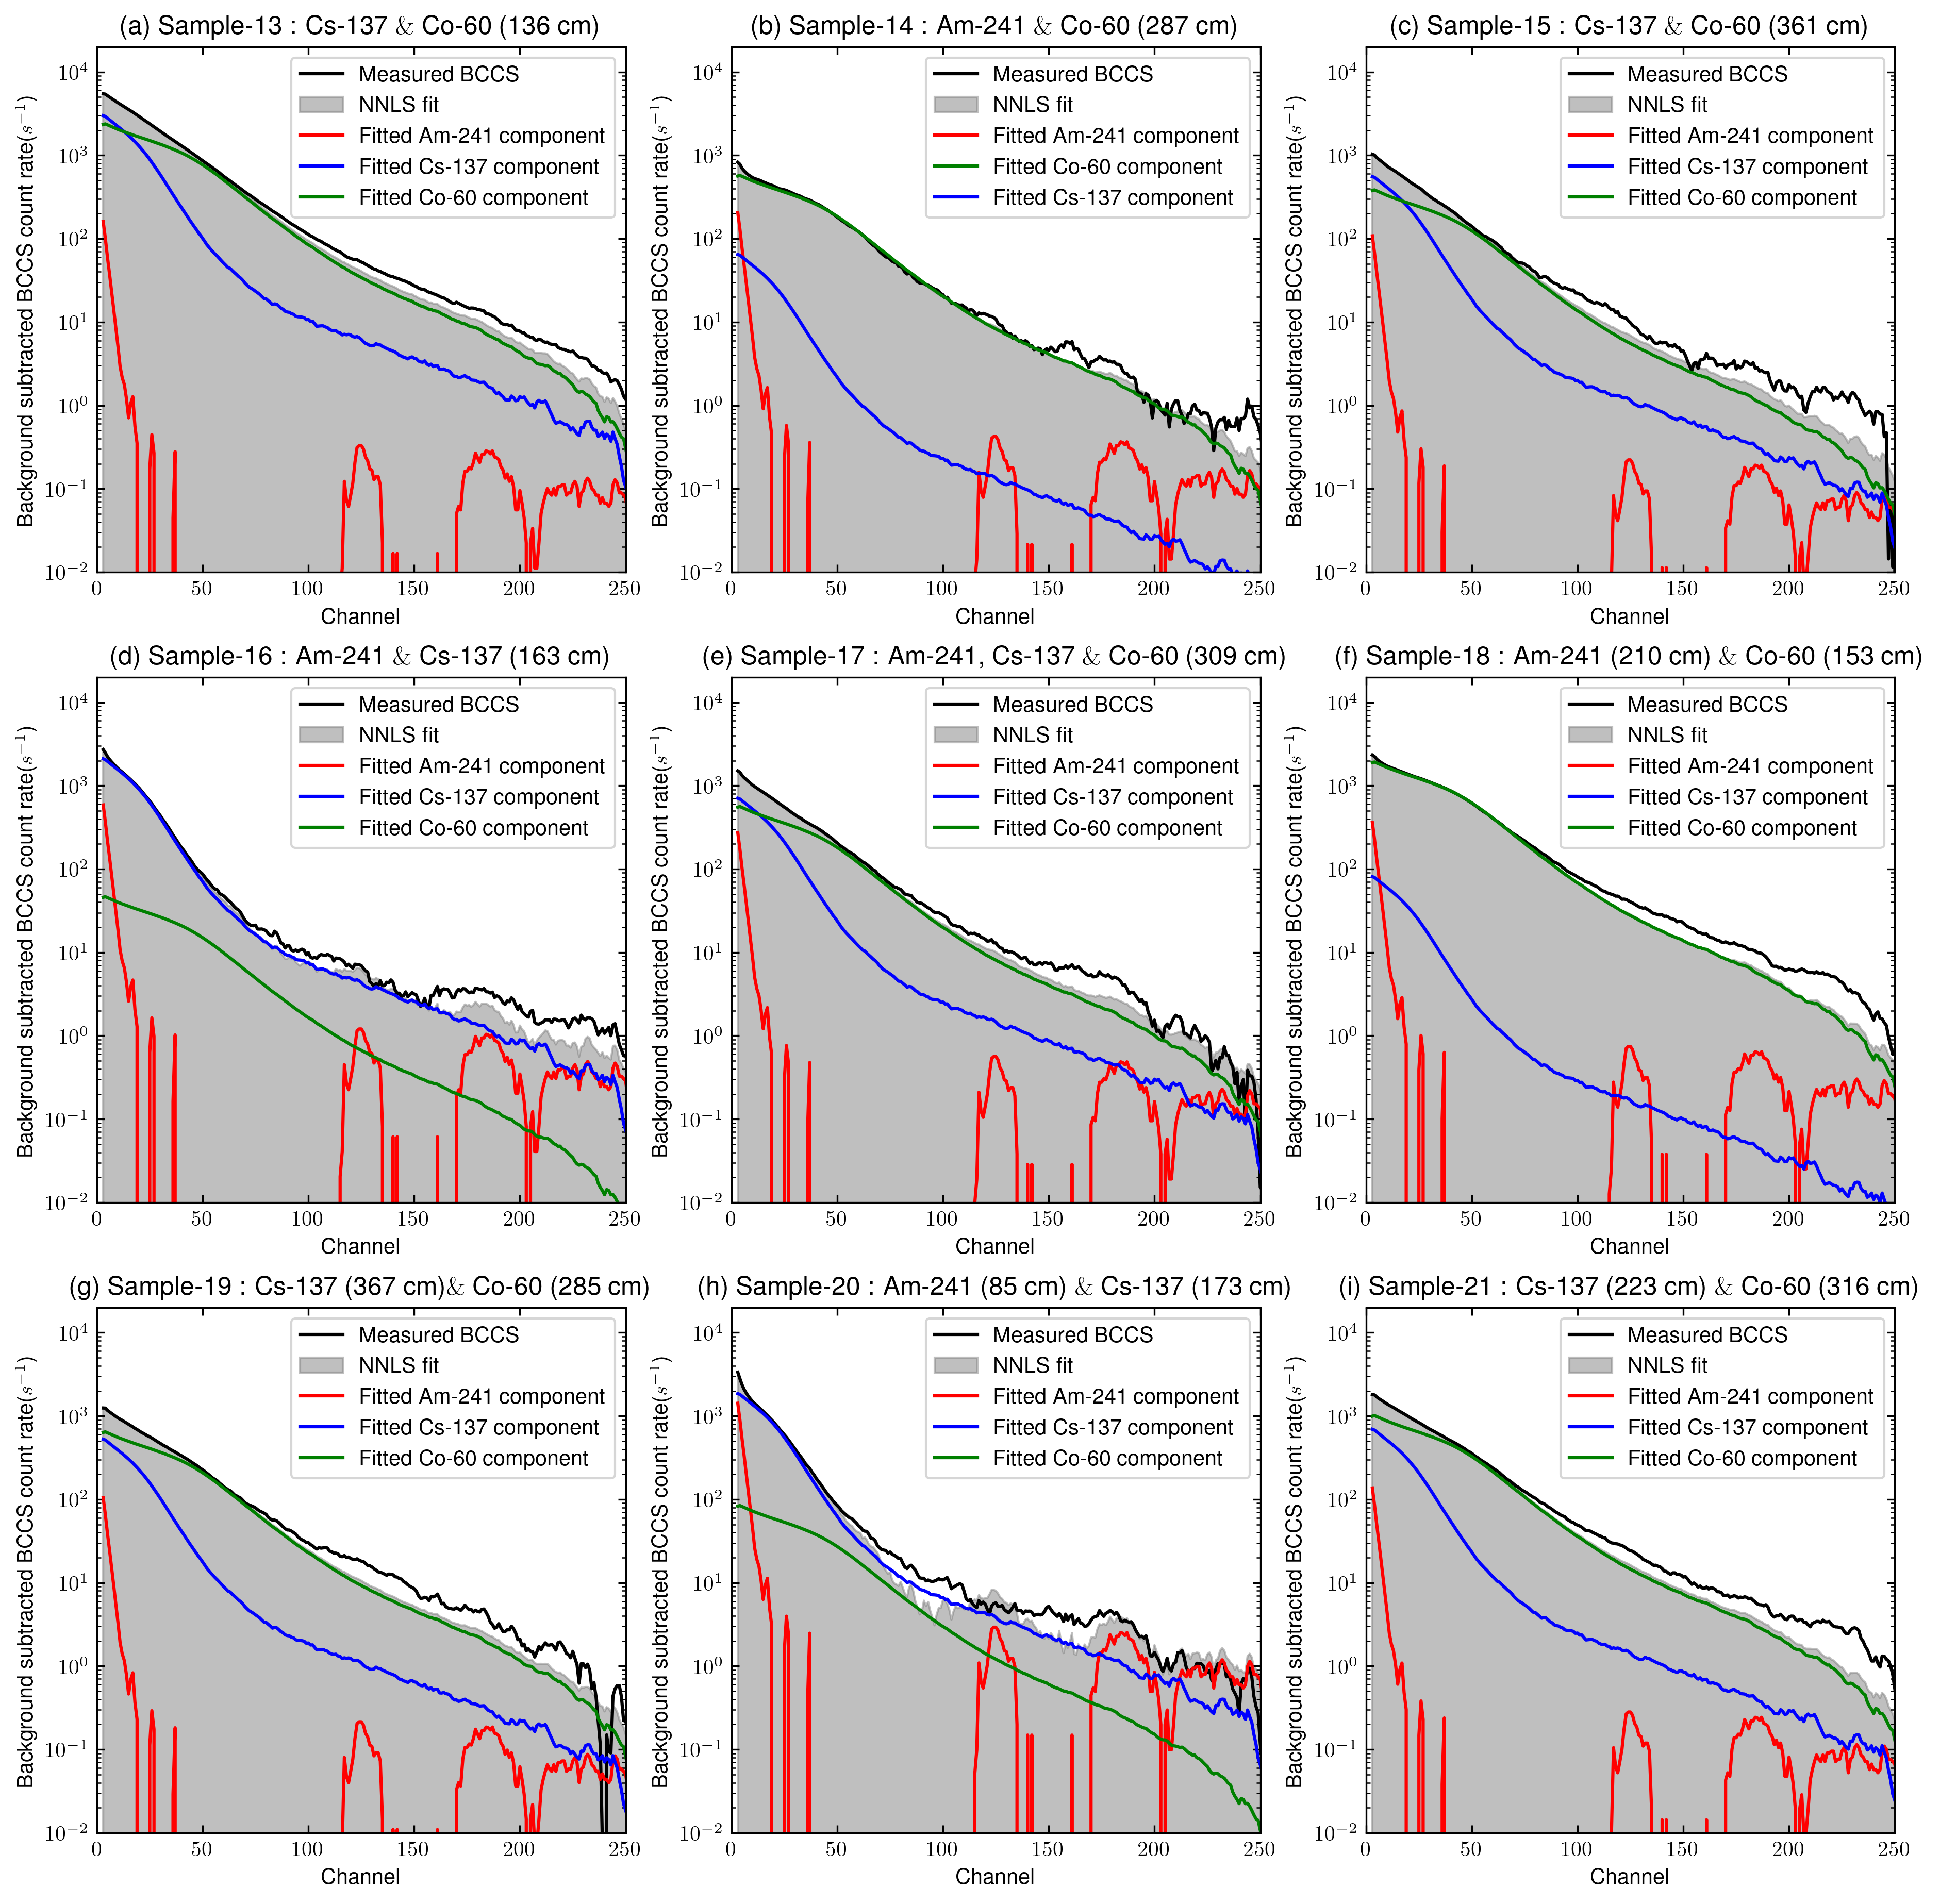

In [47]:
chan1, chan2 = 0, 250
yl1, yl2 = 0.01, 2.0e4
plt.figure(figsize=(15, 15), dpi=300)
plt.subplot(331)
kk = "co_cs_136"
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(a) Sample-13 : Cs-137 $\\&$ Co-60 (136 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend(loc=1)

plt.subplot(332)
kk = "am_co_287"
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.title("(b) Sample-14 : Am-241 $\\&$ Co-60 (287 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.yscale("log", base=10)
plt.legend()

plt.subplot(333)
kk = "co_cs_361"
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(c) Sample-15 : Cs-137 $\\&$ Co-60 (361 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

plt.subplot(334)
kk = 'am_cs_163'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(d) Sample-16 : Am-241 $\\&$ Cs-137 (163 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

plt.subplot(335)
kk = 'am_co_cs_309'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label =  "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(e) Sample-17 : Am-241, Cs-137 $\\&$ Co-60 (309 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

plt.subplot(336)
kk = 'am_210_co_153'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(f) Sample-18 : Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend(loc=1)

plt.subplot(337)
kk = 'co_285_cs_367'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title("(g) Sample-19 : Cs-137 (367 cm)$\\&$ Co-60 (285 cm) ")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

plt.subplot(338)
kk = 'am_85_cs_173'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")

plt.title("(h) Sample-20 : Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

plt.subplot(339)
kk = 'co_316_cs_223'
plt.plot(channel, BCCSSub1[kk], color="black", label = "Measured BCCS")
plt.fill_between(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"] + BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"] + BCCSFitSubResult[kk]['cs'][0]* _refspecSub["Cs"], color="gray", alpha=0.5, label = "NNLS fit")
plt.plot(channel, BCCSFitSubResult[kk]['am'][0] * _refspecSub["Am"], color="red", label = "Fitted Am-241 component")
plt.plot(channel, BCCSFitSubResult[kk]['cs'][0] * _refspecSub["Cs"], color="blue", label = "Fitted Cs-137 component")
plt.plot(channel, BCCSFitSubResult[kk]['co'][0] * _refspecSub["Co"], color="green", label = "Fitted Co-60 component")
plt.title( "(i) Sample-21 : Cs-137 (223 cm) $\\&$ Co-60 (316 cm)")
plt.xlim(chan1, chan2)
plt.ylim(yl1, yl2)
plt.yscale("log", base=10)
plt.xlabel("Channel")
plt.ylabel("Background subtracted BCCS count rate($s^{-1}$)")
plt.legend()

if FLAG_savefig :
    plt.savefig(os.path.join(current_paper_directory, "fit_BGSub.pdf"))
    print("Saved!")
plt.savefig("fit_BGSub.pdf")

KeyError: 'co_223_cs_316'

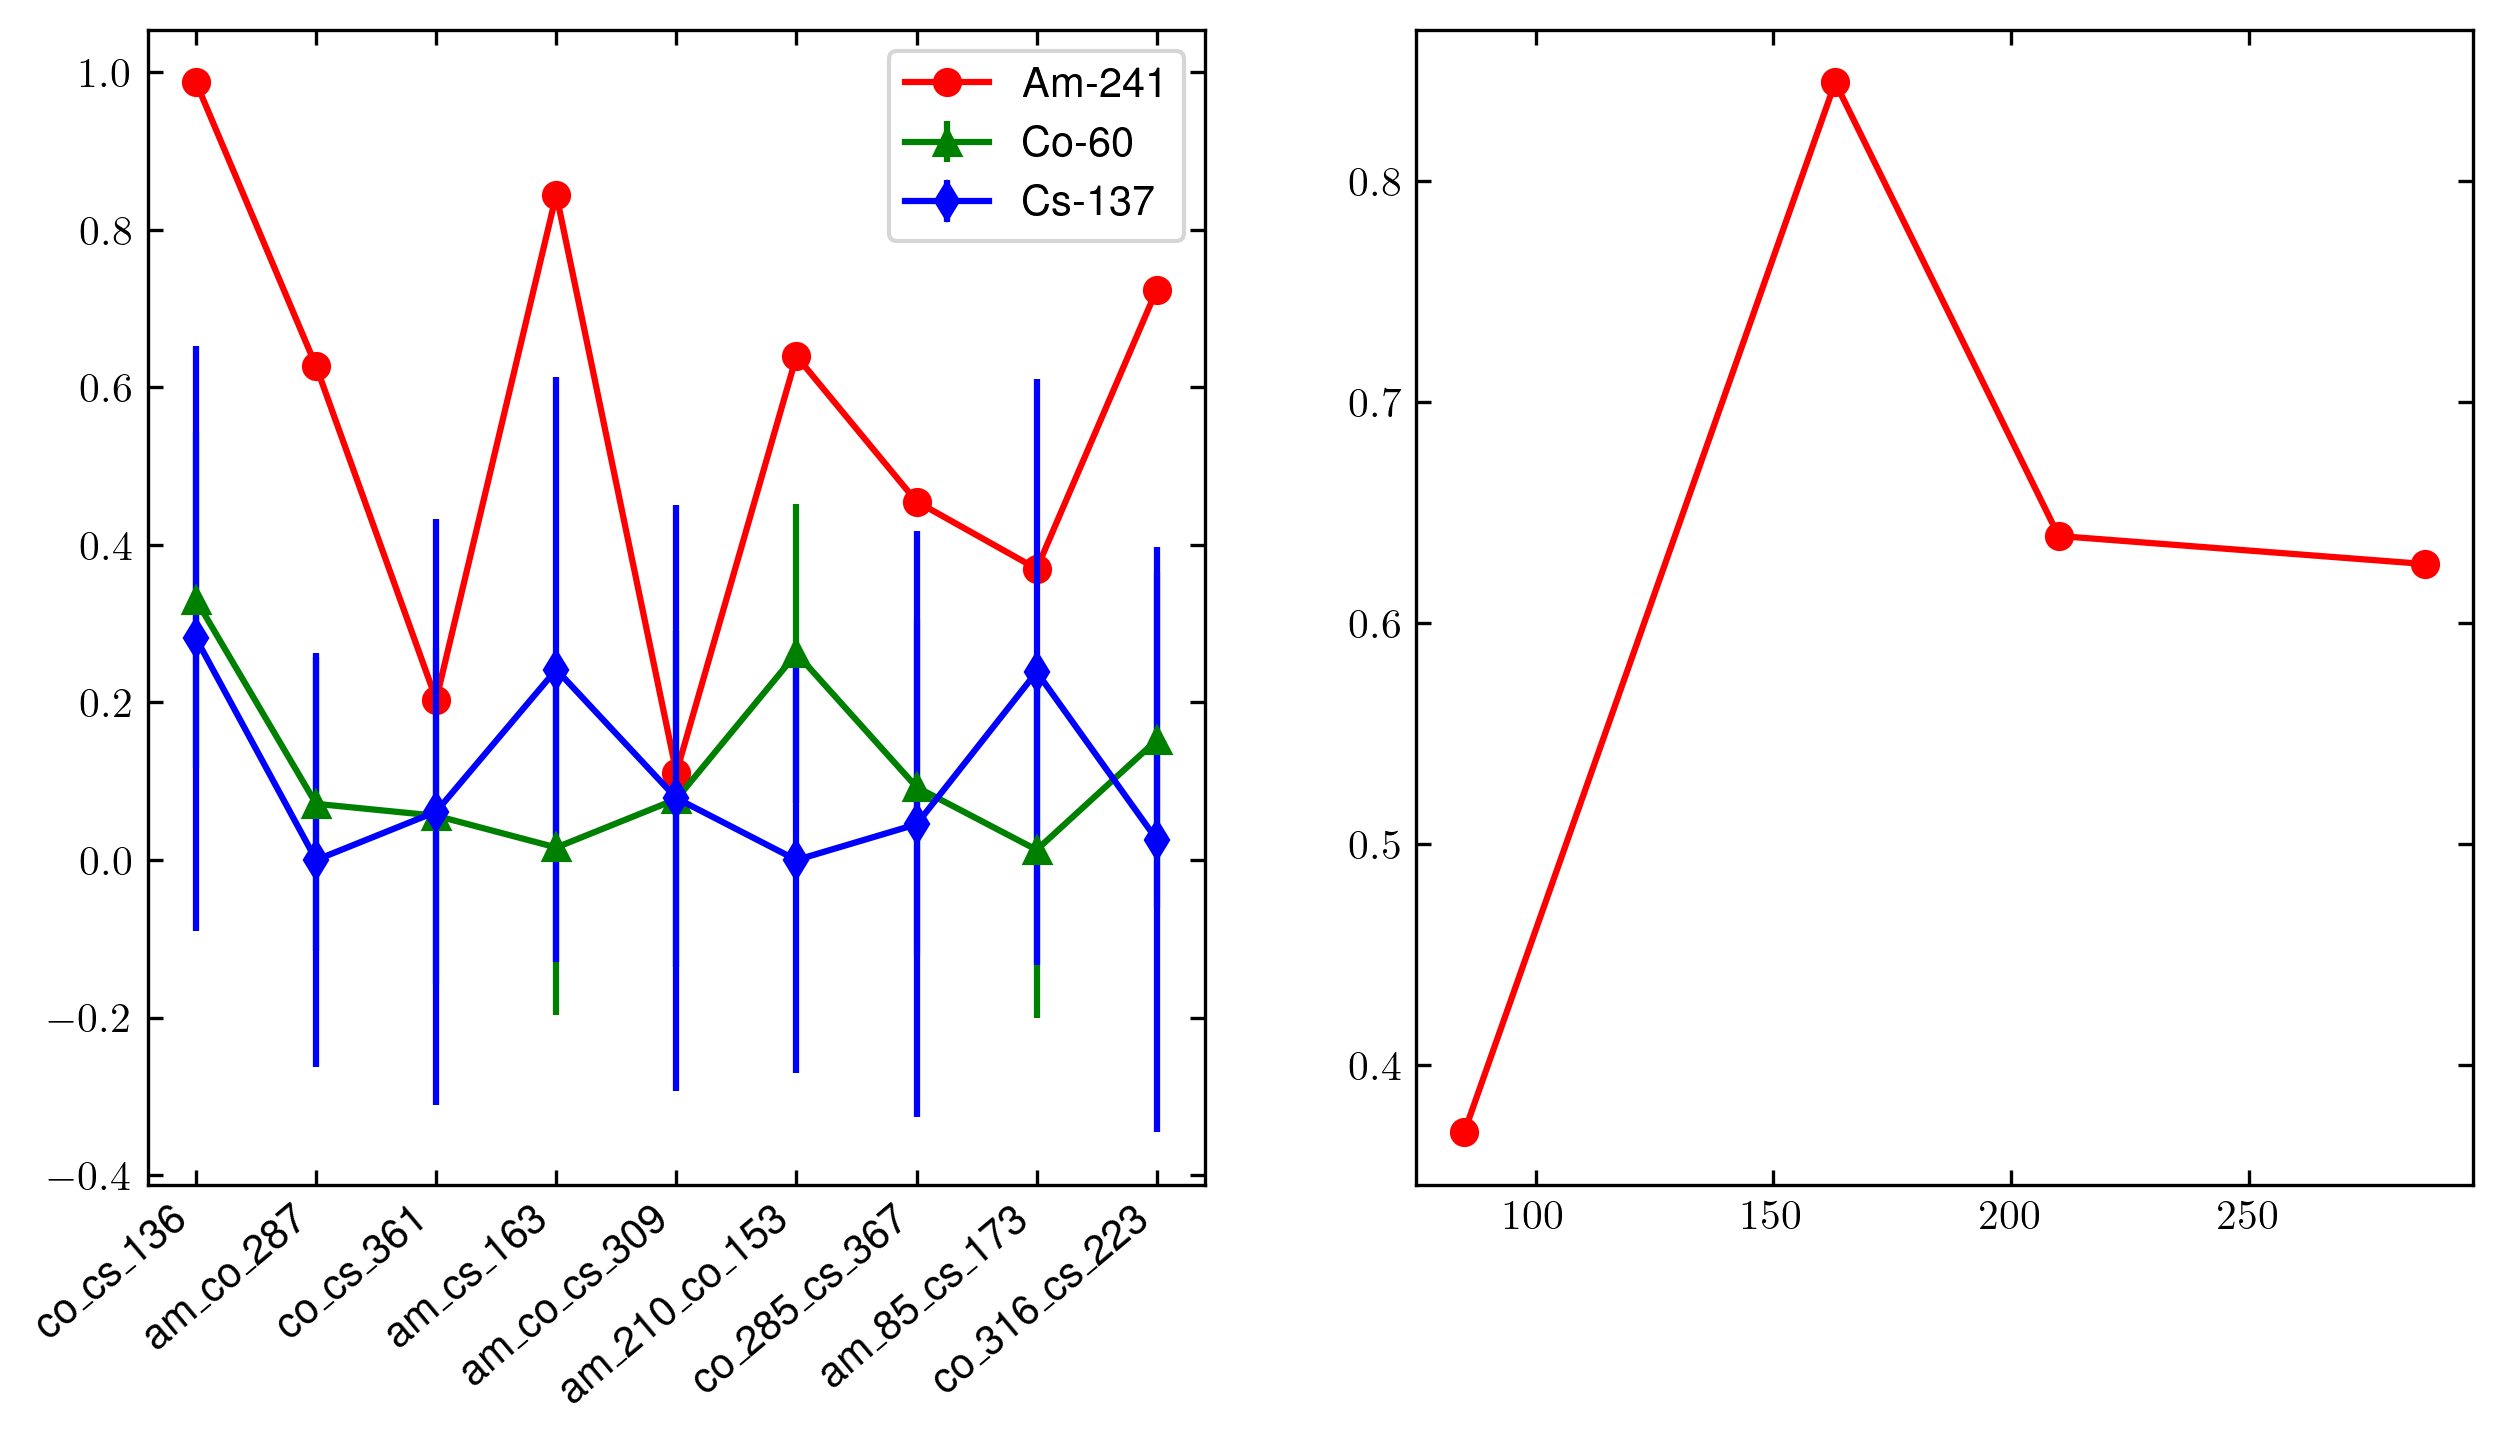

In [13]:
_refspecRto= {"Am" : BCCSRto1["am_80"], "Co" :BCCSRto1["co_60"], "Cs":BCCSRto1["cs_70"]}
mixed = ("co_cs_136", "am_co_287", "co_cs_361", "am_cs_163", "am_co_cs_309", "am_210_co_153",
         "co_285_cs_367", "am_85_cs_173", "co_316_cs_223")

# BCCSFitRtoResult = {}
# for kk in mixed :
#      BCCSFitRtoResult[kk] = BCCSfit((0.5, 0.5, 0.5), BCCSRto1[kk], _refspecRto, 100, False)


Nchan=252
BCCSFitRtoResult0, BCCSFitRtoResult = {}, {}
for kk in mixed :
     popt2, se2, pconv2 = BCCSfit((0.5, 0.5, 0.5), BCCSRto1[kk], _refspecRto, Nchan, False)
     BCCSFitRtoResult0[kk] = (popt2, se2, pconv2)
     BCCSFitRtoResult[kk] = {}
     BCCSFitRtoResult[kk]["am"] = [float(c) for c in (float(popt2[0]), float(np.sqrt(se2[0])))]
     BCCSFitRtoResult[kk]["co"] = [float(c) for c in (float(popt2[1]), float(np.sqrt(se2[1])))]
     BCCSFitRtoResult[kk]["cs"] = [float(c) for c in (float(popt2[2]), float(np.sqrt(se2[2])))]

v_am, v_co, v_cs, e_am, e_co, e_cs = [], [], [], [], [], []
for kk in mixed :
     v_am.append(BCCSFitRtoResult[kk]["am"][0])
     e_am.append(BCCSFitRtoResult[kk]["am"][1])
     v_co.append(BCCSFitRtoResult[kk]["co"][0])
     e_co.append(BCCSFitRtoResult[kk]["co"][1])
     v_cs.append(BCCSFitRtoResult[kk]["cs"][0])
     e_cs.append(BCCSFitRtoResult[kk]["cs"][1])

plt.figure(figsize=(10, 5), dpi = 300)
plt.subplot(121)
#plt.errorbar(mixed, v_am, e_am, color="red", marker="o", label = "Am-241")
plt.plot(mixed, v_am, color="red", marker="o", label = "Am-241")
plt.errorbar(mixed, v_co, e_co, color="green", marker="^", label = "Co-60")
plt.errorbar(mixed, v_cs, e_cs, color="blue", marker="d", label = "Cs-137")
ax=plt.gca()
ax.set_xticks(np.arange(0, len(mixed)))
ax.set_xticklabels(mixed, rotation=40, ha='right')
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitRtoResult["am_co_287"]["am"][0], BCCSFitRtoResult["am_cs_163"]["am"][0], BCCSFitRtoResult["am_210_co_153"]["am"][0], BCCSFitRtoResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitRtoResult["co_cs_136"]["co"][0], BCCSFitRtoResult["am_co_287"]["co"][0], BCCSFitRtoResult["co_cs_361"]["co"][0], BCCSFitRtoResult["am_co_cs_309"]["co"][0], BCCSFitRtoResult["am_210_co_153"]["co"][0], BCCSFitRtoResult["co_285_cs_367"]["co"][0], BCCSFitRtoResult["co_223_cs_316"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitRtoResult["co_cs_136"]["cs"][0], BCCSFitRtoResult["co_cs_361"]["cs"][0], BCCSFitRtoResult["am_cs_163"]["cs"][0], BCCSFitRtoResult["am_co_cs_309"]["cs"][0], BCCSFitRtoResult["co_285_cs_367"]["cs"][0], BCCSFitRtoResult["am_85_cs_173"]["cs"][0], BCCSFitRtoResult["co_223_cs_316"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(0, 1)
plt.xlabel("Source to detector distance [cm]")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
     if "am" not in ks :
          amzero.append(BCCSFitRtoResult[ks]["am"][0])
          
     if "co" not in ks :
          cozero.append(BCCSFitRtoResult[ks]["co"][0])
          
     if "cs" not in ks :
          cszero.append(BCCSFitRtoResult[ks]["cs"][0])
          qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.legend()

In [ ]:
BCCSFitRtoResult

{'co_cs_136': {'am': [0.9869538419670338, 0.5534904385218923],
  'co': [0.33016004576614194, 0.21299959766985221],
  'cs': [0.28131113297217974, 0.3716450543080298]},
 'am_co_287': {'am': [0.626719347199749, 0.5442681835962841],
  'co': [0.07132366085782456, 0.17543133856833124],
  'cs': [1.1530927327279421e-11, 0.0936270439327128]},
 'co_cs_361': {'am': [0.20355251933321583, 0.5534904384669003],
  'co': [0.05615140287636637, 0.2129995969540337],
  'cs': [0.06131596694288611, 0.371645051763718]},
 'am_cs_163': {'am': [0.8446130252796967, 0.5534904378149382],
  'co': [0.015876266892848698, 0.21299959634995946],
  'cs': [0.24172887874995322, 0.3716450493169547]},
 'am_co_cs_309': {'am': [0.11102453519451337, 0.5534904410120871],
  'co': [0.07724227877645304, 0.21299959722560205],
  'cs': [0.0784082863569039, 0.37164505226573424]},
 'am_210_co_153': {'am': [0.6394145624323189, 0.5483128540648748],
  'co': [0.2622111463349434, 0.18061090912349562],
  'cs': [1.9827499054830643e-09, 0.219748

Saved


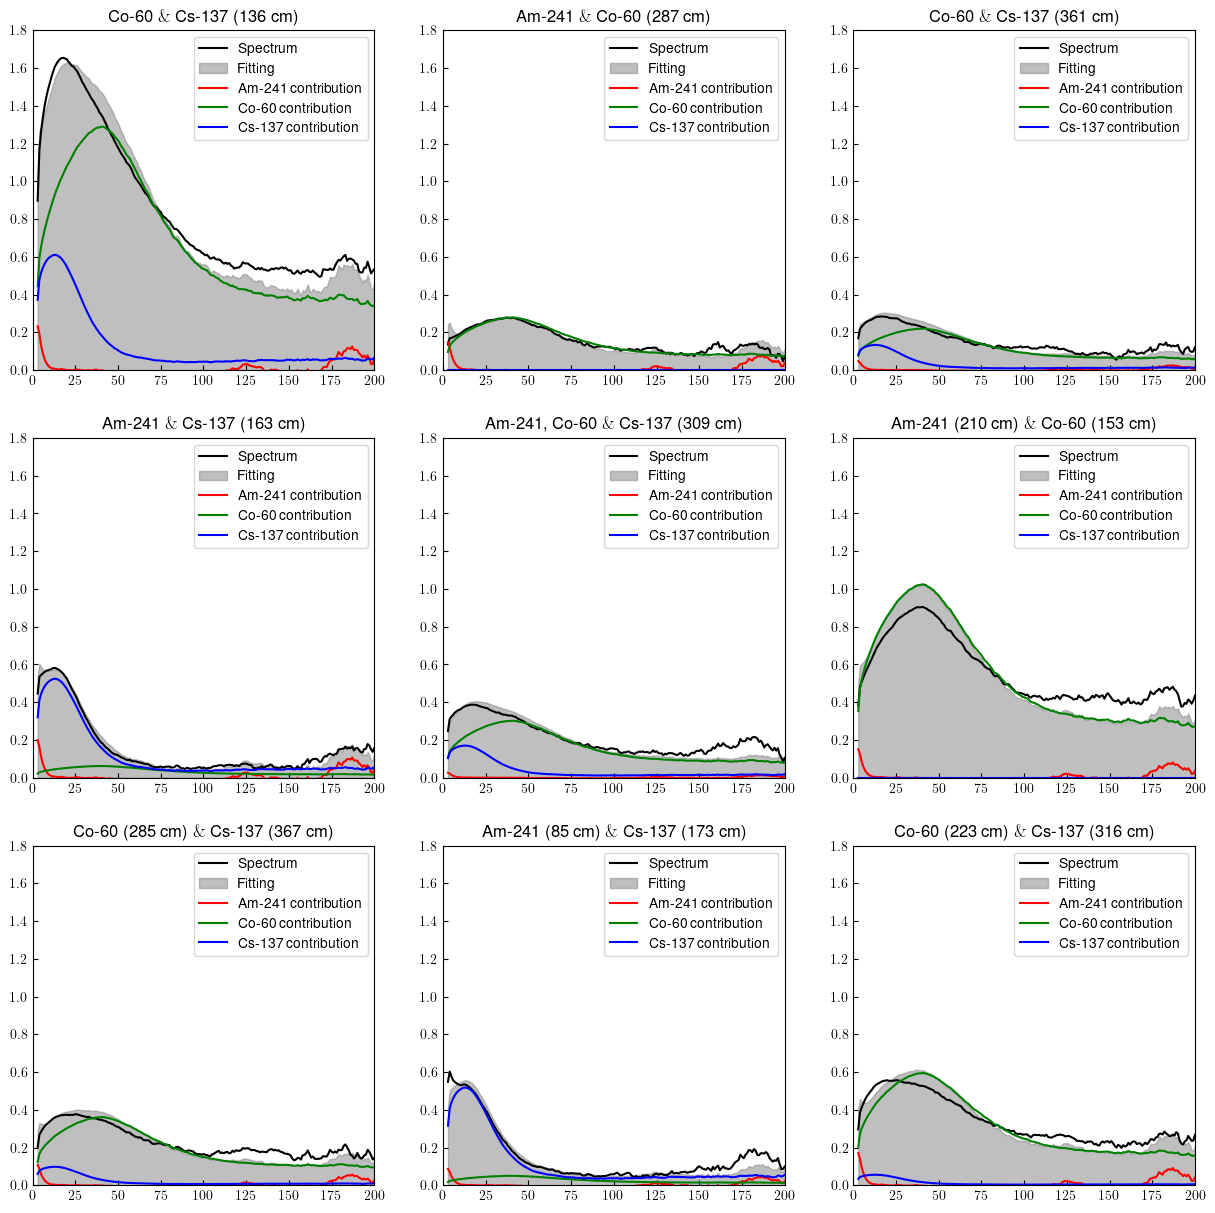

In [ ]:
chan1, chan2 = 0, 200
y0, y1 = 0, 1.8
plt.figure(figsize=(15, 15))#, dpi=300)
plt.subplot(331)
kk = "co_cs_136"
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 $\\&$ Cs-137 (136 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)

plt.legend()

plt.subplot(332)
kk = "am_co_287"
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 $\\&$ Co-60 (287 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(333)
kk = "co_cs_361"
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 $\\&$ Cs-137 (361 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(334)
kk = 'am_cs_163'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title( "Am-241 $\\&$ Cs-137 (163 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(335)
kk = 'am_co_cs_309'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241, Co-60 $\\&$ Cs-137 (309 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
#plt.yscale("log", base=10)
plt.legend()

plt.subplot(336)
kk = 'am_210_co_153'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 (210 cm) $\\&$ Co-60 (153 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
plt.legend(loc=1)

plt.subplot(337)
kk = 'co_285_cs_367'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 (285 cm) $\\&$ Cs-137 (367 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(338)
kk = 'am_85_cs_173'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Am-241 (85 cm) $\\&$ Cs-137 (173 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

plt.subplot(339)
kk = 'co_223_cs_316'
plt.plot(channel, BCCSRto1[kk], color="black", label = "Spectrum")
plt.fill_between(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"] + BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"] + BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color="gray", alpha=0.5, label = "Fitting")
plt.plot(channel, BCCSFitRtoResult[kk]['am'][0] * _refspecRto["Am"], color = "red", label = "Am-241 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['co'][0] * _refspecRto["Co"], color = "green", label = "Co-60 contribution")
plt.plot(channel, BCCSFitRtoResult[kk]['cs'][0] * _refspecRto["Cs"], color = "blue", label = "Cs-137 contribution")
plt.title("Co-60 (223 cm) $\\&$ Cs-137 (316 cm)")
plt.xlim(chan1, chan2)
plt.ylim(y0, y1)
# plt.yscale("log", base=10)
plt.legend()

# plt.savefig("../../src/newfigures/fit_BGRto.pdf")
if FLAG_savefig:
    plt.savefig(os.path.join(current_paper_directory, "fit_BGRto.pdf"))
    print("Saved")

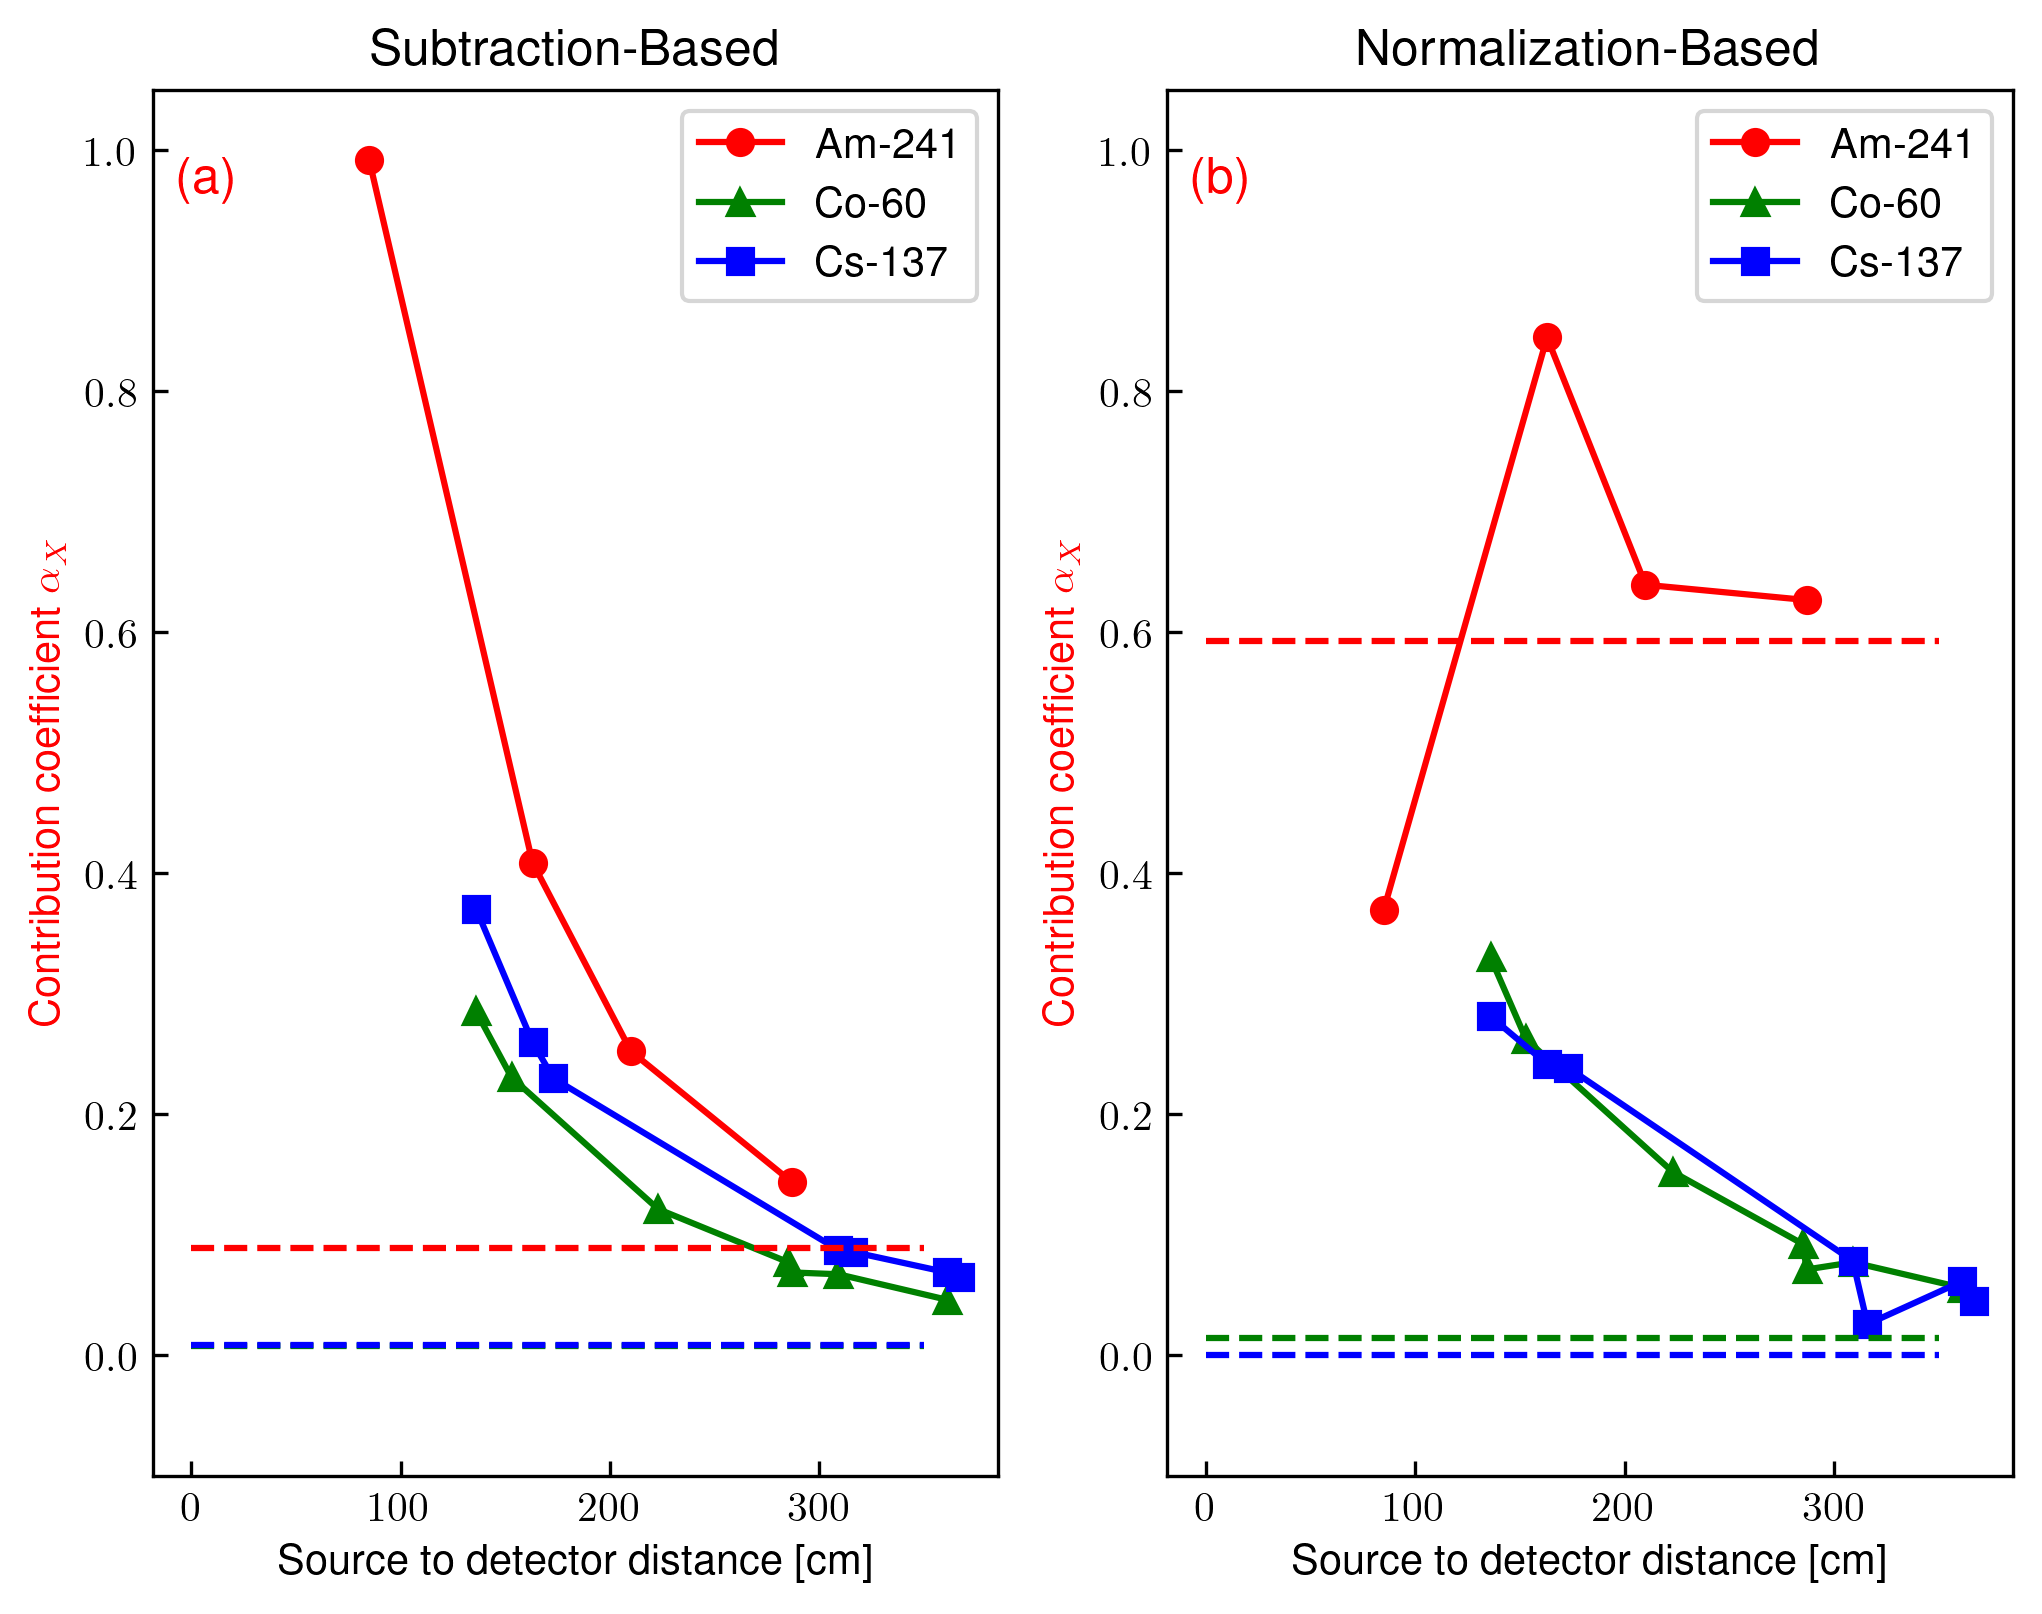

In [ ]:
plt.figure(figsize=(8, 6), dpi=300)

plt.subplot(121)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitSubResult["am_co_287"]["am"][0], BCCSFitSubResult["am_cs_163"]["am"][0], BCCSFitSubResult["am_210_co_153"]["am"][0], BCCSFitSubResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitSubResult["co_cs_136"]["co"][0], BCCSFitSubResult["am_co_287"]["co"][0], BCCSFitSubResult["co_cs_361"]["co"][0], BCCSFitSubResult["am_co_cs_309"]["co"][0], BCCSFitSubResult["am_210_co_153"]["co"][0], BCCSFitSubResult["co_285_cs_367"]["co"][0], BCCSFitSubResult["co_223_cs_316"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitSubResult["co_cs_136"]["cs"][0], BCCSFitSubResult["co_cs_361"]["cs"][0], BCCSFitSubResult["am_cs_163"]["cs"][0], BCCSFitSubResult["am_co_cs_309"]["cs"][0], BCCSFitSubResult["co_285_cs_367"]["cs"][0], BCCSFitSubResult["am_85_cs_173"]["cs"][0], BCCSFitSubResult["co_223_cs_316"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1.05)
plt.xlabel("Source to detector distance [cm]")
plt.ylabel("Contribution coefficient $\\alpha_X$", color="red")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
    if "am" not in ks :
        amzero.append(BCCSFitSubResult[ks]["am"][0])
          
    if "co" not in ks :
        cozero.append(BCCSFitSubResult[ks]["co"][0])
          
    if "cs" not in ks :
        cszero.append(BCCSFitSubResult[ks]["cs"][0])
        qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Subtraction-Based")

plt.gca().annotate(
    "(a)",
    xy=(0, 0.97), xycoords='axes fraction',
    xytext=(+0.5, -0.5), textcoords='offset fontsize',
    fontsize='large', verticalalignment='top', color="red")

plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitRtoResult["am_co_287"]["am"][0], BCCSFitRtoResult["am_cs_163"]["am"][0], BCCSFitRtoResult["am_210_co_153"]["am"][0], BCCSFitRtoResult["am_85_cs_173"]["am"][0]])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")
plt.title("Background Subtracted Method")
plt.legend()

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitRtoResult["co_cs_136"]["co"][0], BCCSFitRtoResult["am_co_287"]["co"][0], BCCSFitRtoResult["co_cs_361"]["co"][0], BCCSFitRtoResult["am_co_cs_309"]["co"][0], BCCSFitRtoResult["am_210_co_153"]["co"][0], BCCSFitRtoResult["co_285_cs_367"]["co"][0], BCCSFitRtoResult["co_223_cs_316"]["co"][0]])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitRtoResult["co_cs_136"]["cs"][0], BCCSFitRtoResult["co_cs_361"]["cs"][0], BCCSFitRtoResult["am_cs_163"]["cs"][0], BCCSFitRtoResult["am_co_cs_309"]["cs"][0], BCCSFitRtoResult["co_285_cs_367"]["cs"][0], BCCSFitRtoResult["am_85_cs_173"]["cs"][0], BCCSFitRtoResult["co_223_cs_316"]["cs"][0]])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 1.05)
plt.xlabel("Source to detector distance [cm]")
plt.ylabel("Contribution coefficient $\\alpha_X$", color="red")

amzero, cozero, cszero, qs= [] , [], [], []

for ks in mixed :
    if "am" not in ks :
        amzero.append(BCCSFitRtoResult[ks]["am"][0])
          
    if "co" not in ks :
        cozero.append(BCCSFitRtoResult[ks]["co"][0])
          
    if "cs" not in ks :
        cszero.append(BCCSFitRtoResult[ks]["cs"][0])
        qs.append(ks)

plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Normalization-Based")
plt.legend()

plt.gca().annotate(
    "(b)",
    xy=(0, 0.97), xycoords='axes fraction',
    xytext=(+0.5, -0.5), textcoords='offset fontsize',
    fontsize='large', verticalalignment='top', color="red")

if FLAG_savefig:
    plt.savefig(os.path.join(current_paper_directory, "fit_contributions.pdf"))

#plt.savefig("sample_21_position_changed.pdf")

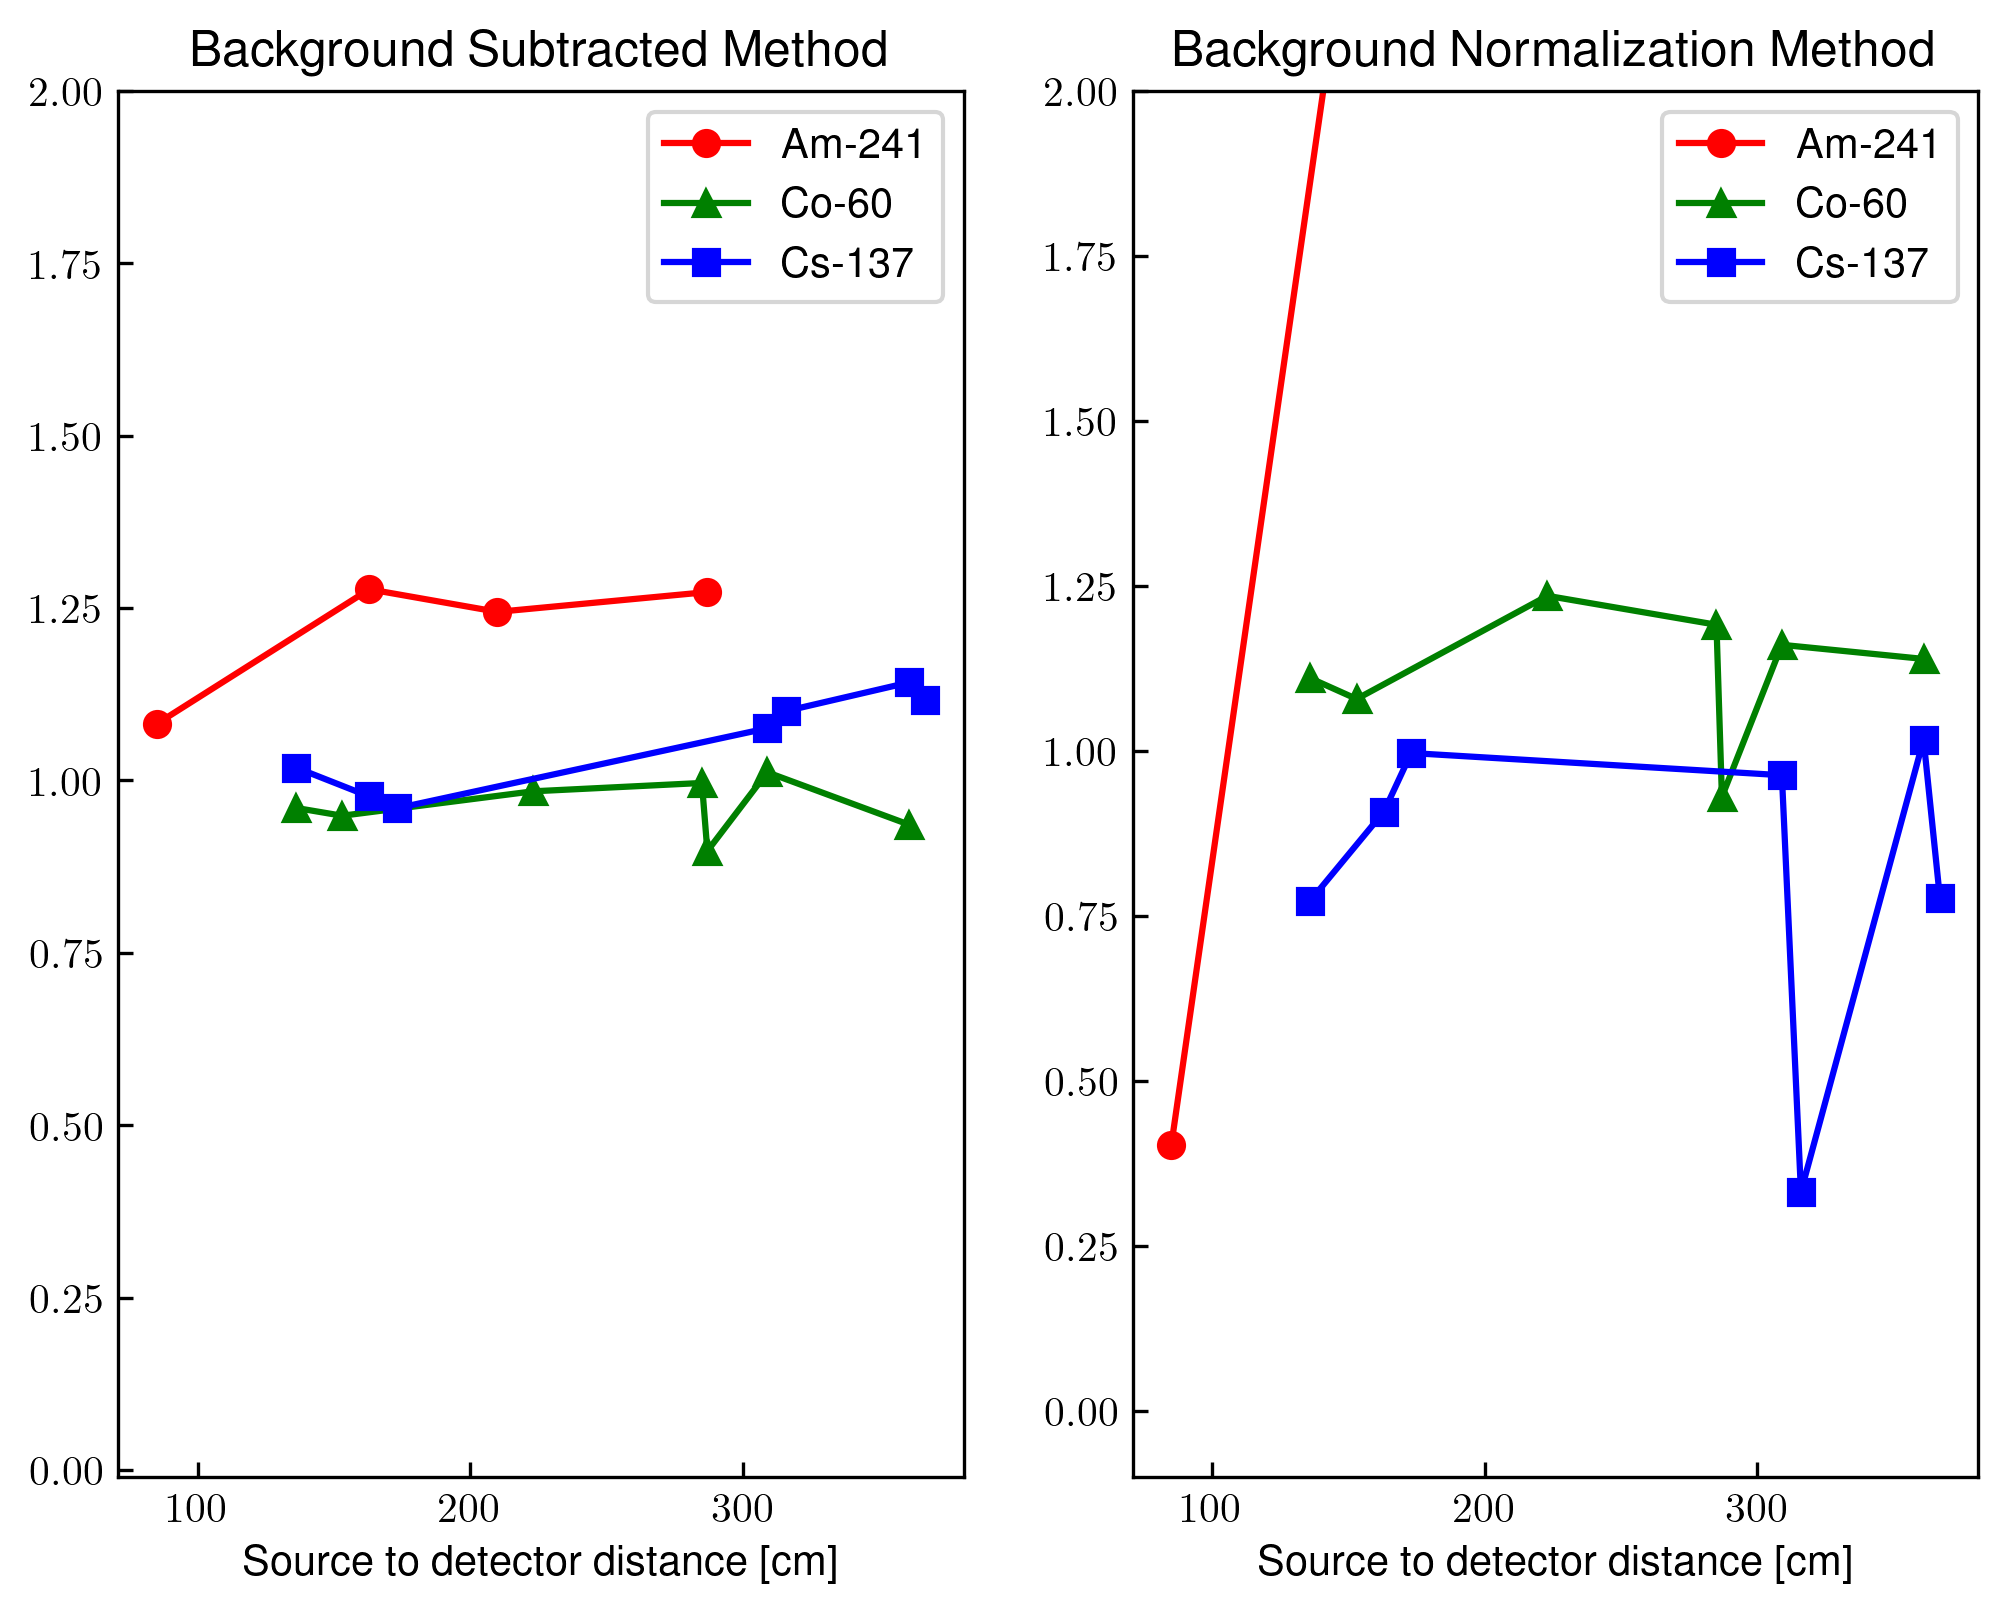

In [ ]:
# Detector solid angle corrected

plt.figure(figsize=(8, 6), dpi=300)

plt.subplot(121)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitSubResult["am_co_287"]["am"][0] * solidangle(80)/solidangle(287), 
                BCCSFitSubResult["am_cs_163"]["am"][0] * solidangle(80)/solidangle(163), 
                BCCSFitSubResult["am_210_co_153"]["am"][0]* solidangle(80)/solidangle(210), 
                BCCSFitSubResult["am_85_cs_173"]["am"][0]* solidangle(80)/solidangle(85)])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitSubResult["co_cs_136"]["co"][0] * solidangle(60)/solidangle(136), 
                BCCSFitSubResult["am_co_287"]["co"][0] * solidangle(60)/solidangle(287), 
                BCCSFitSubResult["co_cs_361"]["co"][0] * solidangle(60)/solidangle(361), 
                BCCSFitSubResult["am_co_cs_309"]["co"][0] * solidangle(60)/solidangle(309), 
                BCCSFitSubResult["am_210_co_153"]["co"][0] * solidangle(60)/solidangle(153), 
                BCCSFitSubResult["co_285_cs_367"]["co"][0] * solidangle(60)/solidangle(285), 
                BCCSFitSubResult["co_223_cs_316"]["co"][0] * solidangle(60)/solidangle(223)])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitSubResult["co_cs_136"]["cs"][0] * solidangle(70)/solidangle(136), 
                BCCSFitSubResult["co_cs_361"]["cs"][0] * solidangle(70)/solidangle(361), 
                BCCSFitSubResult["am_cs_163"]["cs"][0] * solidangle(70)/solidangle(163), 
                BCCSFitSubResult["am_co_cs_309"]["cs"][0] * solidangle(70)/solidangle(309), 
                BCCSFitSubResult["co_285_cs_367"]["cs"][0] * solidangle(70)/solidangle(367), 
                BCCSFitSubResult["am_85_cs_173"]["cs"][0] * solidangle(70)/solidangle(173), 
                BCCSFitSubResult["co_223_cs_316"]["cs"][0] * solidangle(70)/solidangle(316)])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.01, 2)
plt.xlabel("Source to detector distance [cm]")

# amzero, cozero, cszero, qs= [] , [], [], []

# for ks in mixed :
#      if "am" not in ks :
#           amzero.append(BCCSFitSubResult[ks]["am"][0])
          
#      if "co" not in ks :
#           cozero.append(BCCSFitSubResult[ks]["co"][0])
          
#      if "cs" not in ks :
#           cszero.append(BCCSFitSubResult[ks]["cs"][0])
#           qs.append(ks)

# plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
# plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
# plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Background Subtracted Method")
plt.legend()

plt.subplot(122)
amx = np.array([287, 163, 210, 85])
amy = np.array([BCCSFitRtoResult["am_co_287"]["am"][0] * solidangle(80)/solidangle(287), 
                BCCSFitRtoResult["am_cs_163"]["am"][0] * solidangle(80)/solidangle(163), 
                BCCSFitRtoResult["am_210_co_153"]["am"][0] * solidangle(80)/solidangle(210), 
                BCCSFitRtoResult["am_85_cs_173"]["am"][0] * solidangle(80)/solidangle(85)])
sort_list = np.argsort(amx)
amx = amx[sort_list]
amy = amy[sort_list]
plt.plot(amx, amy, "ro-", label = "Am-241")
plt.title("Background Subtracted Method")
plt.legend()

cox = np.array([136, 287, 361, 309, 153, 285, 223])
coy = np.array([BCCSFitRtoResult["co_cs_136"]["co"][0] * solidangle(60)/solidangle(136), 
                BCCSFitRtoResult["am_co_287"]["co"][0] * solidangle(60)/solidangle(287), 
                BCCSFitRtoResult["co_cs_361"]["co"][0] * solidangle(60)/solidangle(361), 
                BCCSFitRtoResult["am_co_cs_309"]["co"][0] * solidangle(60)/solidangle(309), 
                BCCSFitRtoResult["am_210_co_153"]["co"][0] * solidangle(60)/solidangle(153), 
                BCCSFitRtoResult["co_285_cs_367"]["co"][0] * solidangle(60)/solidangle(285), 
                BCCSFitRtoResult["co_223_cs_316"]["co"][0] * solidangle(60)/solidangle(223) ])
sort_list = np.argsort(cox)
cox = cox[sort_list]
coy = coy[sort_list]
plt.plot(cox, coy, "g^-", label = "Co-60")

csx = np.array([136, 361, 163, 309, 367, 173, 316])
csy = np.array([BCCSFitRtoResult["co_cs_136"]["cs"][0] * solidangle(70)/solidangle(136), 
                BCCSFitRtoResult["co_cs_361"]["cs"][0] * solidangle(70)/solidangle(361), 
                BCCSFitRtoResult["am_cs_163"]["cs"][0] * solidangle(70)/solidangle(163), 
                BCCSFitRtoResult["am_co_cs_309"]["cs"][0] * solidangle(70)/solidangle(309), 
                BCCSFitRtoResult["co_285_cs_367"]["cs"][0] * solidangle(70)/solidangle(367), 
                BCCSFitRtoResult["am_85_cs_173"]["cs"][0] * solidangle(70)/solidangle(173), 
                BCCSFitRtoResult["co_223_cs_316"]["cs"][0] * solidangle(70)/solidangle(316)])
sort_list = np.argsort(csx)
csx = csx[sort_list]
csy = csy[sort_list]
plt.plot(csx, csy, "bs-", label = "Cs-137")

plt.ylim(-0.1, 2)
plt.xlabel("Source to detector distance [cm]")

# amzero, cozero, cszero, qs= [] , [], [], []

# for ks in mixed :
#      if "am" not in ks :
#           amzero.append(BCCSFitRtoResult[ks]["am"][0])
          
#      if "co" not in ks :
#           cozero.append(BCCSFitRtoResult[ks]["co"][0])
          
#      if "cs" not in ks :
#           cszero.append(BCCSFitRtoResult[ks]["cs"][0])
#           qs.append(ks)

# plt.hlines(np.mean(amzero),0, 350, "red", "dashed" )
# plt.hlines(np.mean(cozero),0, 350, "green", "dashed" )
# plt.hlines(np.mean(cszero),0, 350, "blue", "dashed" )

plt.title("Background Normalization Method")
plt.legend()

plt.savefig("solid_angle_normalized.pdf")

In [ ]:
BCCSFitResult

NameError: name 'BCCSFitResult' is not defined

In [ ]:
(80/85)**2

0.8858131487889274

In [ ]:
BCCSFitSubResult["am_85_cs_173"]["am"][0]

0.9919667768880771